# Main-paper display items — figures and tables with explanations

**Purpose.** This notebook assembles the main-text display items of the paper
("The learning-consistent required subsidy", outline: `z-ethan/paper_outline.md`):
six figures and Table 1. The Table 2 slot is a freed reserve (2026-08-19: the
Monte Carlo variables table moved to the SI as ST10, in the appendix notebook).
Every panel is the already-generated, checked artifact from the analysis
notebooks. This notebook does not redraw any of them. Each item carries a
**source block** that names the notebook and cell that made each panel.
To change a panel, edit it there and re-run this notebook.

**How to read this notebook.** Each section has three parts:
1. A text block that explains the item in plain language.
2. A code cell that composes the panels and writes `figures/FigN_*.png`.
3. A printed draft caption, collected into `exports/captions_main.txt`.

**Language.** We use simplified technical English: short sentences, one
idea per sentence, active voice. Terms of art are kept, but each one is
glossed in the table below.

**What the paper claims, in one paragraph.** Cost assumptions and deployment
targets are set independently in current practice, and nothing enforces
their consistency. We couple them: Monte Carlo learning-conditional cost
worlds feed a capacity mandate in ReEDS, and the mandate's shadow price is
the subsidy that makes the pair consistent. The minimum public cost of each
target — the floor — is a flat dollar-per-MW payment at commissioning,
31–332 B$ (present value, median worlds) across the ambition ladder. The
subsidy behaves like a bridge (it decays as the fleet learns) in cheap
worlds, but not in expensive ones. Translated into the US tax credit,
median worlds need 2.0–2.5 times the current base credit, and the uniform
percentage credit costs 1.17–1.25 times the floor.

## Glossary — read this first

We use each term below many times. We give its plain meaning once, here.
The same word always has the same meaning in this notebook.

| Term | Plain meaning |
|---|---|
| **Schedule** | A target path for new US nuclear capacity, in gigawatts (GW), from now to 2050. The paper prices six schedules. It does not rank or endorse them. |
| **Mandate** | A rule added to the model: "at least this much new nuclear capacity must exist in year t." Each schedule becomes one mandate. |
| **ReEDS** | The national power-system planning model (NREL). It chooses the cheapest mix of plants and transmission that meets demand and all rules. |
| **Shadow price (dual)** | The price the model puts on the mandate rule. It equals the yearly rental payment, per kilowatt of mandated capacity, that would just make builders willing to build. Units: dollars per kW per year, in 2024 dollars. A shadow price of zero means the mandate needs no subsidy that year. The main text says "shadow price"; "dual" is the optimization term, used only in Methods (and in the exported file and column names, which keep it). |
| **Learning rate** | The percent cost drop each time total built capacity doubles. Example: a 10% learning rate means the second 10 GW costs 10% less per kW than the first 10 GW. |
| **Learning curve** | The cost path that a learning rate produces as capacity grows. |
| **OCC (overnight capital cost)** | The cost to build a plant if it could be built "overnight" — no construction-period interest. Units: \$/kW. |
| **Financed capex** | OCC plus the interest that accrues during the construction years. Long builds raise it. |
| **SMR / large** | The two reactor technology families: small modular reactors, and large conventional reactors. |
| **Cost world** | One complete random draw of all uncertain cost inputs (learning rates, starting costs, build durations, and so on). The Monte Carlo makes 10,000 worlds per schedule. |
| **P5 / P50 / P95 world** | Actual single draws ranked by total program cost: a cheap world (5th percentile), the median world, and an expensive world (95th percentile). |
| **Conditional cost trajectory** | A cost path that is only valid if its paired deployment schedule actually happens. None of our cost fans is a forecast. |
| **ITC (investment tax credit)** | The main US subsidy instrument: the government returns a set percentage of a plant's capital cost through the tax system. The current base credit (section 48E) is 30%, with bonuses up to about 50%. |
| **Model credit convention (i_model)** | The paper's headline rate convention: the credit is valued inside ReEDS's own financing arithmetic, where a credit dollar also carries construction-period carrying cost. Two real designs deliver it (a progress payment during construction, or a placed-in-service claim on the interest-inclusive tax basis), and both cost the government the same present value. The exported companion i_pis = i_model x ccmult converts to a placed-in-service credit on an overnight-cost-only basis. |
| **The floor / instrument menu** | The floor is the minimum net government cost that delivers the required support to every build — a flat dollar-per-MW payment at commissioning with no monetization loss. It is the cost benchmark, not a proposed design; the menu prices every instrument as a multiple of it. |
| **κ (kappa) coupling** | A dial for how strongly the two technologies' cost uncertainties move together. κ = 1: what is expensive for one is expensive for the other. κ = 0: independent. The grid couples two uncertainties separately: the learning rates, and the anchor costs. |
| **Anchor cost (BOAK)** | Each technology's 2030 starting cost, in \$/kW: the point that pins its learning curve. The Monte Carlo draws it per technology. |
| **Decoupled-anchor probe** | One cell of the dependence grid: the two technologies' learning rates stay fully coupled, but each technology draws its anchor cost independently. This differs from κ = 0, which decouples both. It is the hardest cell for SMR, because a large program can draw a cheap start against an expensive SMR one. |
| **EVPI (expected value of perfect information)** | The most that knowing the true cost world in advance could be worth, as a share of expected program cost. |
| **LP / reduced cost** | ReEDS solves a linear program (LP) — a cost-minimization with linear rules. A builder's "reduced cost" is its cost disadvantage at the optimum; zero means it is competitive at the margin. |

In [1]:
import pandas as pd

import paperlib as P
from paperlib import (MC_FIG, MC_EXP, S3_FIG, S3_EXP, S4_FIG, S4_EXP, S3C_EXP,
                      S4C_EXP, ITCFB_FIG, ITCFB_EXP, ITCFBM_FIG, ITCFBM_EXP,
                      BD_FIG, BD_EXP)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
TO2024 = P.to2024()
print(f"repo: {P.REPO}")
print(f"2004$ -> 2024$ multiplier (from inputs/financials/deflator.csv): {TO2024:.4f}")

repo: C:\Users\ethan\code\research\ReEDS-nuclear-learning
2004$ -> 2024$ multiplier (from inputs/financials/deflator.csv): 1.6590


## Figure 1 — Where the ATB 2050 costs sit in learning space

**What this shows.** The NREL Annual Technology Baseline (ATB) publishes
nuclear cost trajectories that many models consume as inputs. Our 2030
anchor convention discards pre-2030 experience by design, so no engine
path can match an ATB trajectory year by year; the paper therefore scores
only the **2050 endpoint** — the 2050 cost, and the builds required to
reach it (Ethan, 08-21/08-24). Panels (a, b): the cost–deployment plane —
for each amount of cumulative building by 2050, the 2050 overnight cost
that the defensible worlds deliver (fan across support-restricted grid
worlds), with the ATB 2050 target as a black dot at its paired
Abou-Jaoude deployment; large reactors (a), SMR (b). Panels (c, d):
endpoint feasibility maps — the shortfall of the 2050 cost against each
target over learning rate × spillover, with a contour bounding the worlds
that reach the target within \$250/kW. Both halves split tiny-base
(learning clock restarts) vs full-stock (legacy fleet credited) rows.

**How to read it.** In (a, b), a dot below the fan means fewer than 5% of
defensible worlds reach that cost at that amount of building; reading
right along the target's dotted line shows how much building would put
the target inside the fan. In (c, d), feasibility is **one-sided**:
a world counts when it reaches the target or beats it (overshoot is
success, not misfit). Each scenario is scored at its own paired
deployment — conservative 12, moderate 33, advanced 199 GW — so
cross-scenario comparisons reflect the ATB's pairing structure, not the
targets alone.

**Key results.** The engine is pinned to the ATB's source: run at
Abou-Jaoude's own parameters and experience basis, it reproduces his
published SMR OCC tables within report rounding (max error \$500/kW).
Reaching an ATB 2050 cost at its paired deployment takes a firm-level
learning rate of 12.5–18% at the central discrete world (tiny base,
spillover-dependent; T5) against the source study's own 9.5% — the gap
is the expected anchor-convention premium, and it puts the large targets
at or above the top of large's sampled support (3–12%). On the
support-restricted grid the feasible shares are 1.1–7.6% for the large
targets and 12.5–31.9% for SMR — the cheaper scenarios owe their wider
reach to the much larger deployments the ATB pairs them with. Under
full-stock accounting no large target is reachable at all: zero feasible
worlds in all three scenarios, and no learning rate up to 30% closes the
gap at the paired deployment — every large trajectory presumes
fresh-start accounting (the empty-contour full-stock rows in c). The
differences from the source are designed basis conventions (anchor
convention, experience basis; SN7), not disagreements. This inversion
uses about 0.79 million sampled worlds per target and zero ReEDS runs.

composed -> z-ethan\paper_figures\figures\Fig1_atb_placement.png  (7904x4505 px)


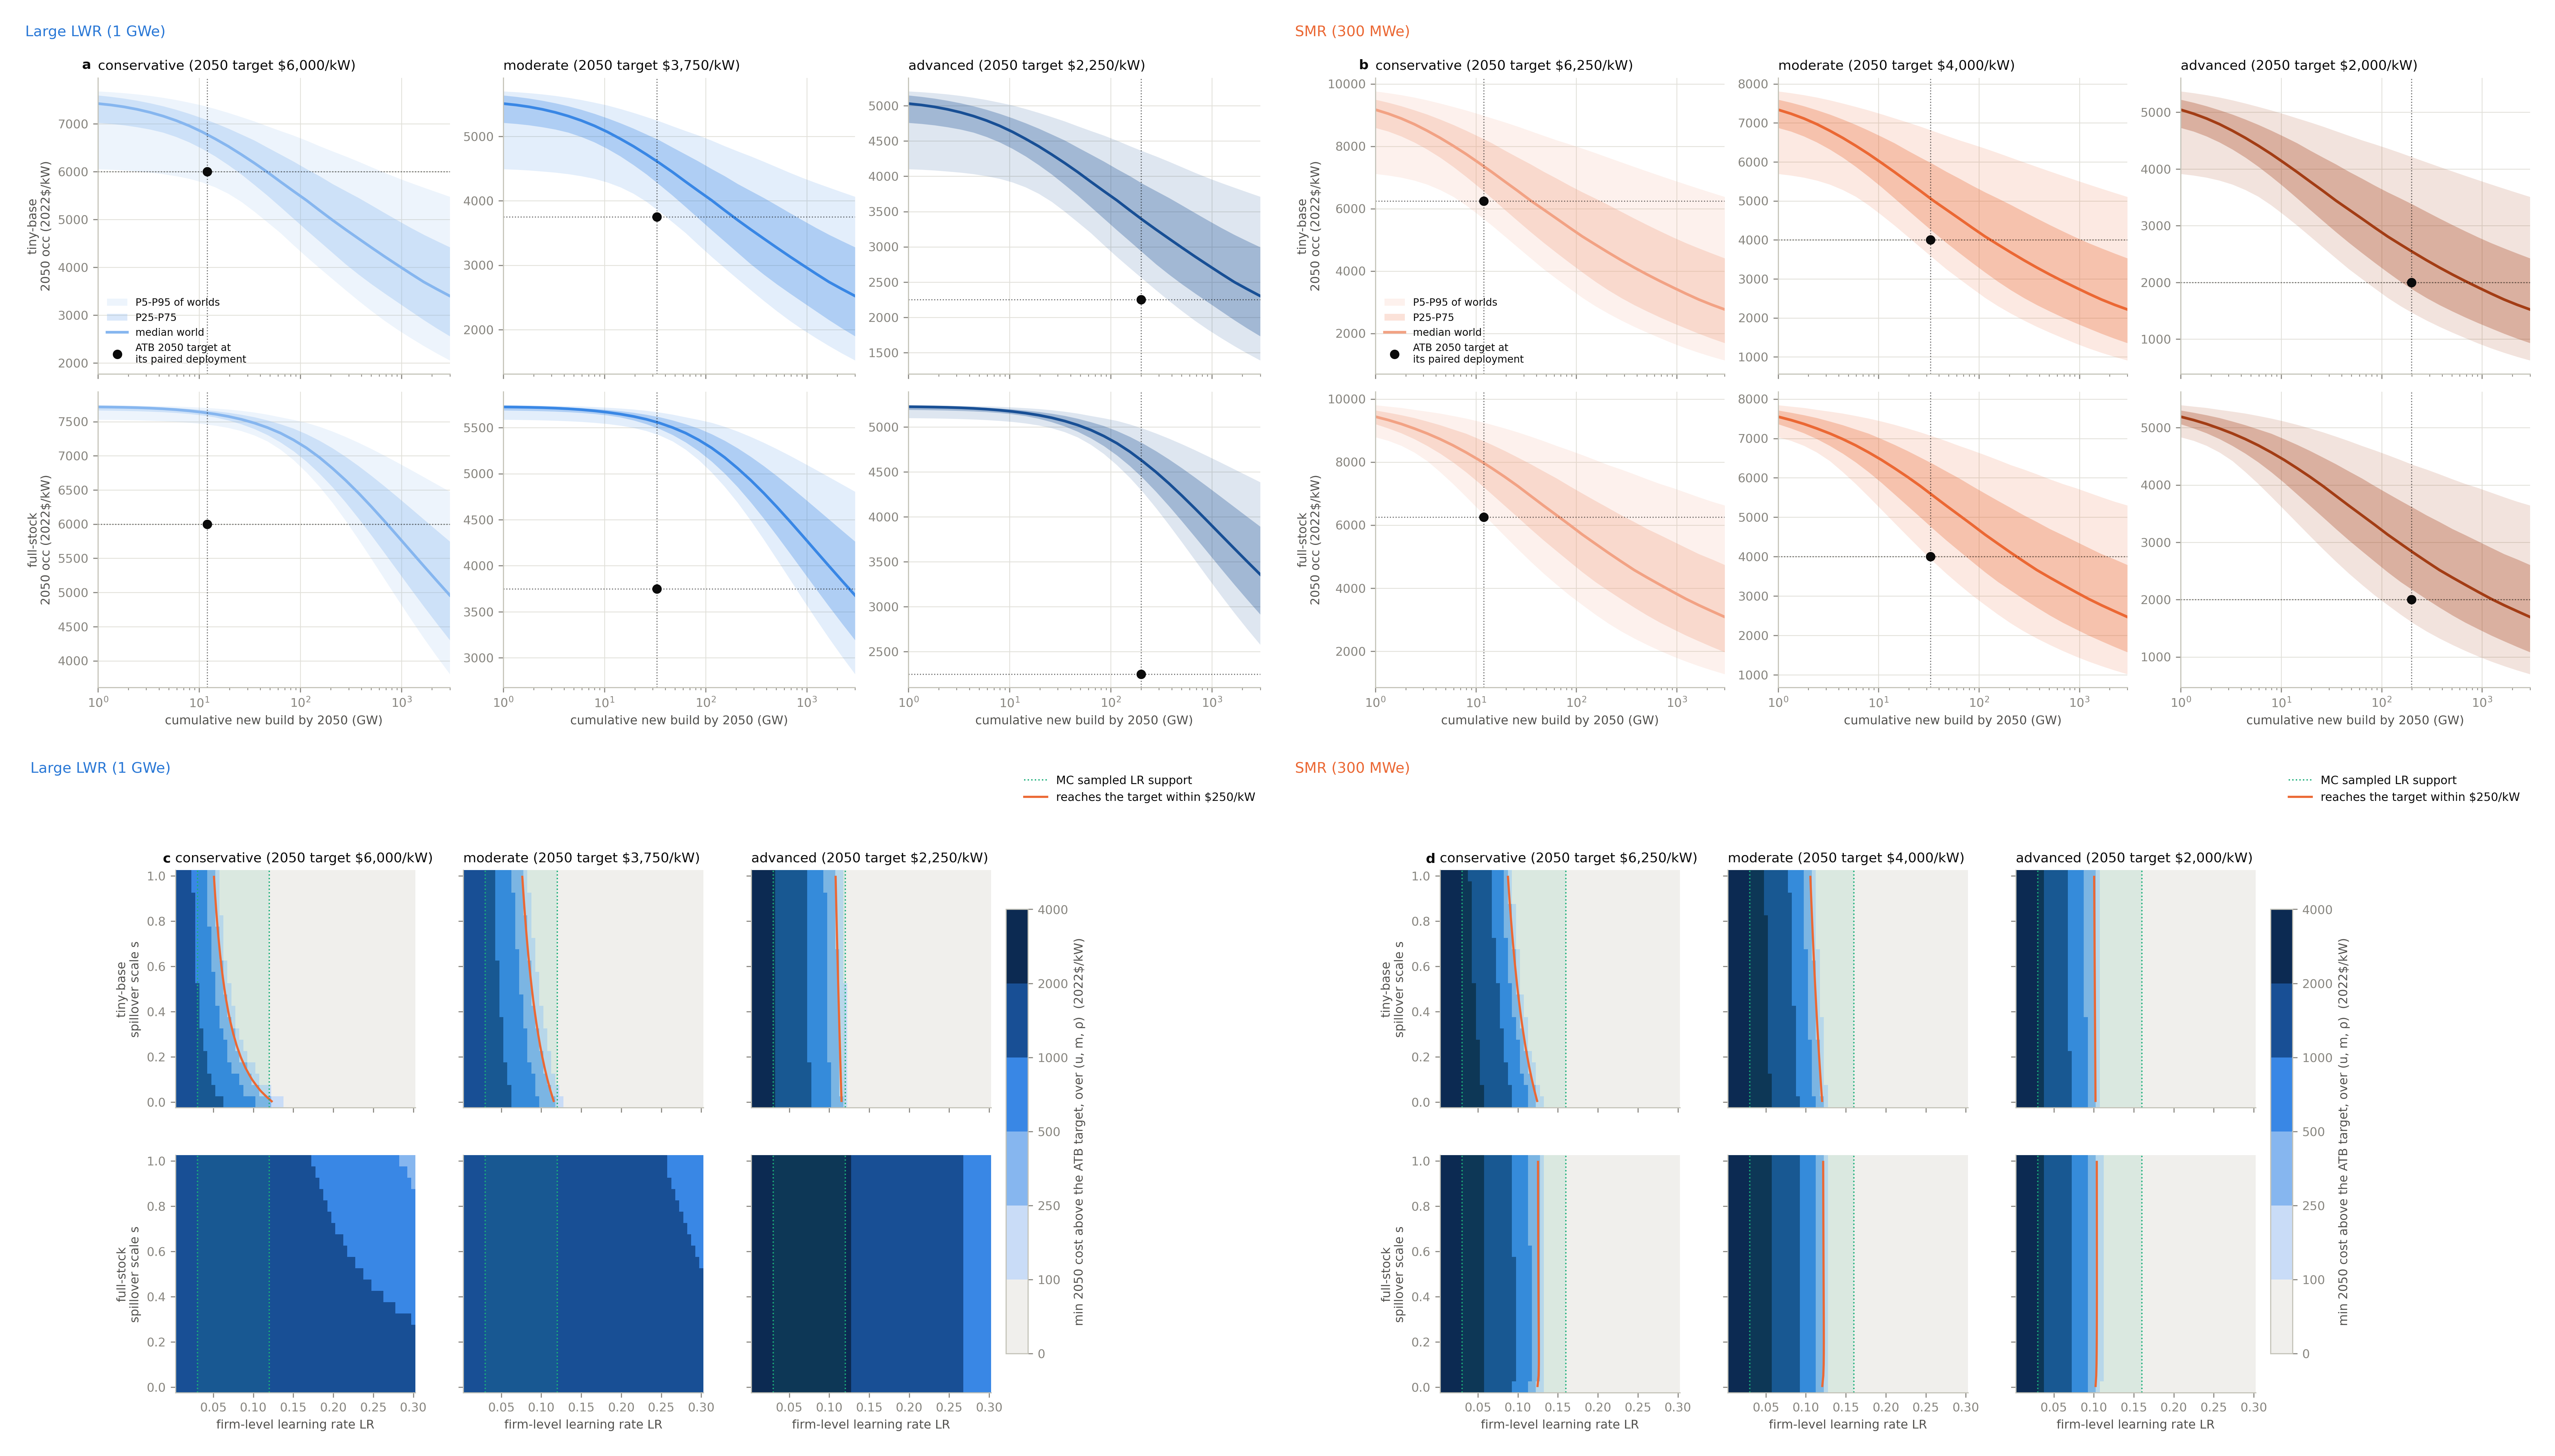

**Sources — edit the figure at its origin, not here:**

- `z-ethan\mc\figures\atb_cost_deployment_plane_large.png` — generated by `mc/atb_parameter_space.ipynb` (cell F8 (2050-endpoint reframing, 08-24)) from the closed-form 2050 evaluator over the support-restricted Part-2 grid
- `z-ethan\mc\figures\atb_cost_deployment_plane_smr.png` — generated by `mc/atb_parameter_space.ipynb` (cell F8) from same evaluator, SMR
- `z-ethan\mc\figures\atb_endpoint_feasible_maps_large.png` — generated by `mc/atb_parameter_space.ipynb` (cell F9 (one-sided criterion, 08-24)) from 2050 shortfall per world at the paired deployment; shares: `mc/exports/atb/endpoint_feasible_share.csv`
- `z-ethan\mc\figures\atb_endpoint_feasible_maps_smr.png` — generated by `mc/atb_parameter_space.ipynb` (cell F9) from same shortfalls, SMR

 tech     scenario  share_grid  share_support  share_support_tiny  share_support_full  share_support_twosided  share_support_milestone
large conservative      0.2968         0.0761              0.1523              0.0000                  0.0525                   0.0000
large     moderate      0.2930         0.0369              0.0738              0.0000                  0.0355                   0.0174
large     advanced      0.2912         0.0107              0.0214              0.0000                  0.0107                   0.0045
  smr conservative      0.4778         0.1246              0.1956              0.0536                  0.0790                   0.0032
  smr     moderate      0.5024         0.1490              0.2113              0.0866                  0.1110                   0.0086
  smr     advanced      0.6071         0.3186              0.3770              0.2601                  0.1988                   0.0003

min firm-level LR to reach the 2050 cost at the paired

In [2]:
P.compose(
    [[MC_FIG / "atb_cost_deployment_plane_large.png", MC_FIG / "atb_cost_deployment_plane_smr.png"],
     [MC_FIG / "atb_endpoint_feasible_maps_large.png", MC_FIG / "atb_endpoint_feasible_maps_smr.png"]],
    "Fig1_atb_placement.png",
    letters="",  # all four sources carry their letters (a/b plane, c/d maps)
    center=True,
)
P.source_ref(
    (MC_FIG / "atb_cost_deployment_plane_large.png", "mc/atb_parameter_space.ipynb",
     "cell F8 (2050-endpoint reframing, 08-24)",
     "the closed-form 2050 evaluator over the support-restricted Part-2 grid"),
    (MC_FIG / "atb_cost_deployment_plane_smr.png", "mc/atb_parameter_space.ipynb",
     "cell F8", "same evaluator, SMR"),
    (MC_FIG / "atb_endpoint_feasible_maps_large.png", "mc/atb_parameter_space.ipynb",
     "cell F9 (one-sided criterion, 08-24)",
     "2050 shortfall per world at the paired deployment; shares: `mc/exports/atb/endpoint_feasible_share.csv`"),
    (MC_FIG / "atb_endpoint_feasible_maps_smr.png", "mc/atb_parameter_space.ipynb",
     "cell F9", "same shortfalls, SMR"),
)

es = pd.read_csv(MC_EXP / "atb" / "endpoint_feasible_share.csv")
print(es.to_string(index=False))
t5 = pd.read_csv(MC_EXP / "atb" / "min_lr_at_aj_deployment.csv")
tiny = t5[t5["base"] == "tiny"]
lr_cols = [c for c in t5.columns if c.startswith("min LR")]
lr_lo, lr_hi = tiny[lr_cols].min().min(), tiny[lr_cols].max().max()
print(f"\nmin firm-level LR to reach the 2050 cost at the paired deployment "
      f"(tiny base, central world): {lr_lo:.3f}-{lr_hi:.3f}")
lg, sm = es[es["tech"] == "large"], es[es["tech"] == "smr"]
assert float(lg["share_support_full"].max()) == 0.0    # the full-stock large claim
print(f"support-restricted feasible shares (one-sided): "
      f"large {100*lg['share_support'].min():.1f}-{100*lg['share_support'].max():.1f}%, "
      f"smr {100*sm['share_support'].min():.1f}-{100*sm['share_support'].max():.1f}%; "
      f"large full-stock: 0 in all three scenarios")

P.caption("Fig 1", f'''
Where the ATB 2050 nuclear costs sit in learning space (endpoint basis: the 2030 anchor
convention discards pre-2030 experience by design, so only the 2050 cost and the builds
that reach it are scored). (a, b) The cost-deployment plane for large reactors (a) and
SMR (b): the 2050 overnight cost delivered across support-restricted learning worlds
(P5-P95 and P25-P75 fans, median line) as a function of cumulative new build, tiny-base
vs full-stock experience accounting; black dots mark each ATB 2050 target at its paired
deployment. (c, d) Endpoint feasibility maps: the 2050 shortfall against each target
over learning rate x spillover, with the $250/kW reach contour; feasibility is
one-sided (overshoot is success). Reaching a target at its paired deployment takes a
firm-level rate of {100*lr_lo:.3g}-{100*lr_hi:.3g}% at the central world against the
source's own 9.5%; feasible shares on the sampled support are
{100*lg['share_support'].min():.1f}-{100*lg['share_support'].max():.1f}% (large) and
{100*sm['share_support'].min():.1f}-{100*sm['share_support'].max():.1f}% (SMR), and
under full-stock accounting no large target is reachable at any learning rate up to
30%. The engine reproduces the ATB source's published tables under its own parameters
and experience basis (max error $500/kW); the differences are designed basis
conventions. ~0.79M sampled worlds per target; no ReEDS runs.
''')

## Figure 2 — The six schedules, and the cost worlds each one implies

**What this shows.** Panel (a): the six deployment schedules (the "ambition
ladder"), from 117 GW (EIA) to 400 GW (2025 Executive Order) of new capacity
by 2050. One schedule per source type: modeled projection, study assumption,
intergovernmental outlook, consultancy outlook, pledge, policy aspiration.
Panels (b) and (c): for each schedule, the fan of overnight capital cost
(OCC) paths that our Monte Carlo produces **conditional on that schedule
happening** — large reactors in (b), SMR in (c).

**How to read it.** Each fan is a distribution, never a single projection.
The band spans the 5th to 95th percentile of 10,000 joint draws; the middle
line is the median. Each fan begins in 2025 at that draw's first-of-a-kind
premium and descends into its 2030 anchor cost (a plot-only backcast of the
FOAK→BOAK approach and the completion of the world's committed construction
pipeline); the schedules only separate the fans after 2030, when the US
build programs begin. More ambitious schedules buy more learning, so their
fans sit lower.

**Key results.** The median SMR cost in 2050 falls from about \$5,494/kW
under the least ambitious schedule (EIA, 117 GW) to about \$3,483/kW under
the most ambitious (EO, 400 GW). Across schedules the 5th–95th percentile
span runs from roughly \$1,700 to \$8,200/kW. The wide bands are the point:
a deployment target does not pin down a cost; it pins down a distribution.

**Discipline to keep in every caption.** These are conditional cost
trajectories. Each fan answers: "if this schedule happens, what may costs
do?" It never answers: "what will costs be?"

composed -> z-ethan\paper_figures\figures\Fig2_schedules_and_cost_fans.png  (3965x4012 px)


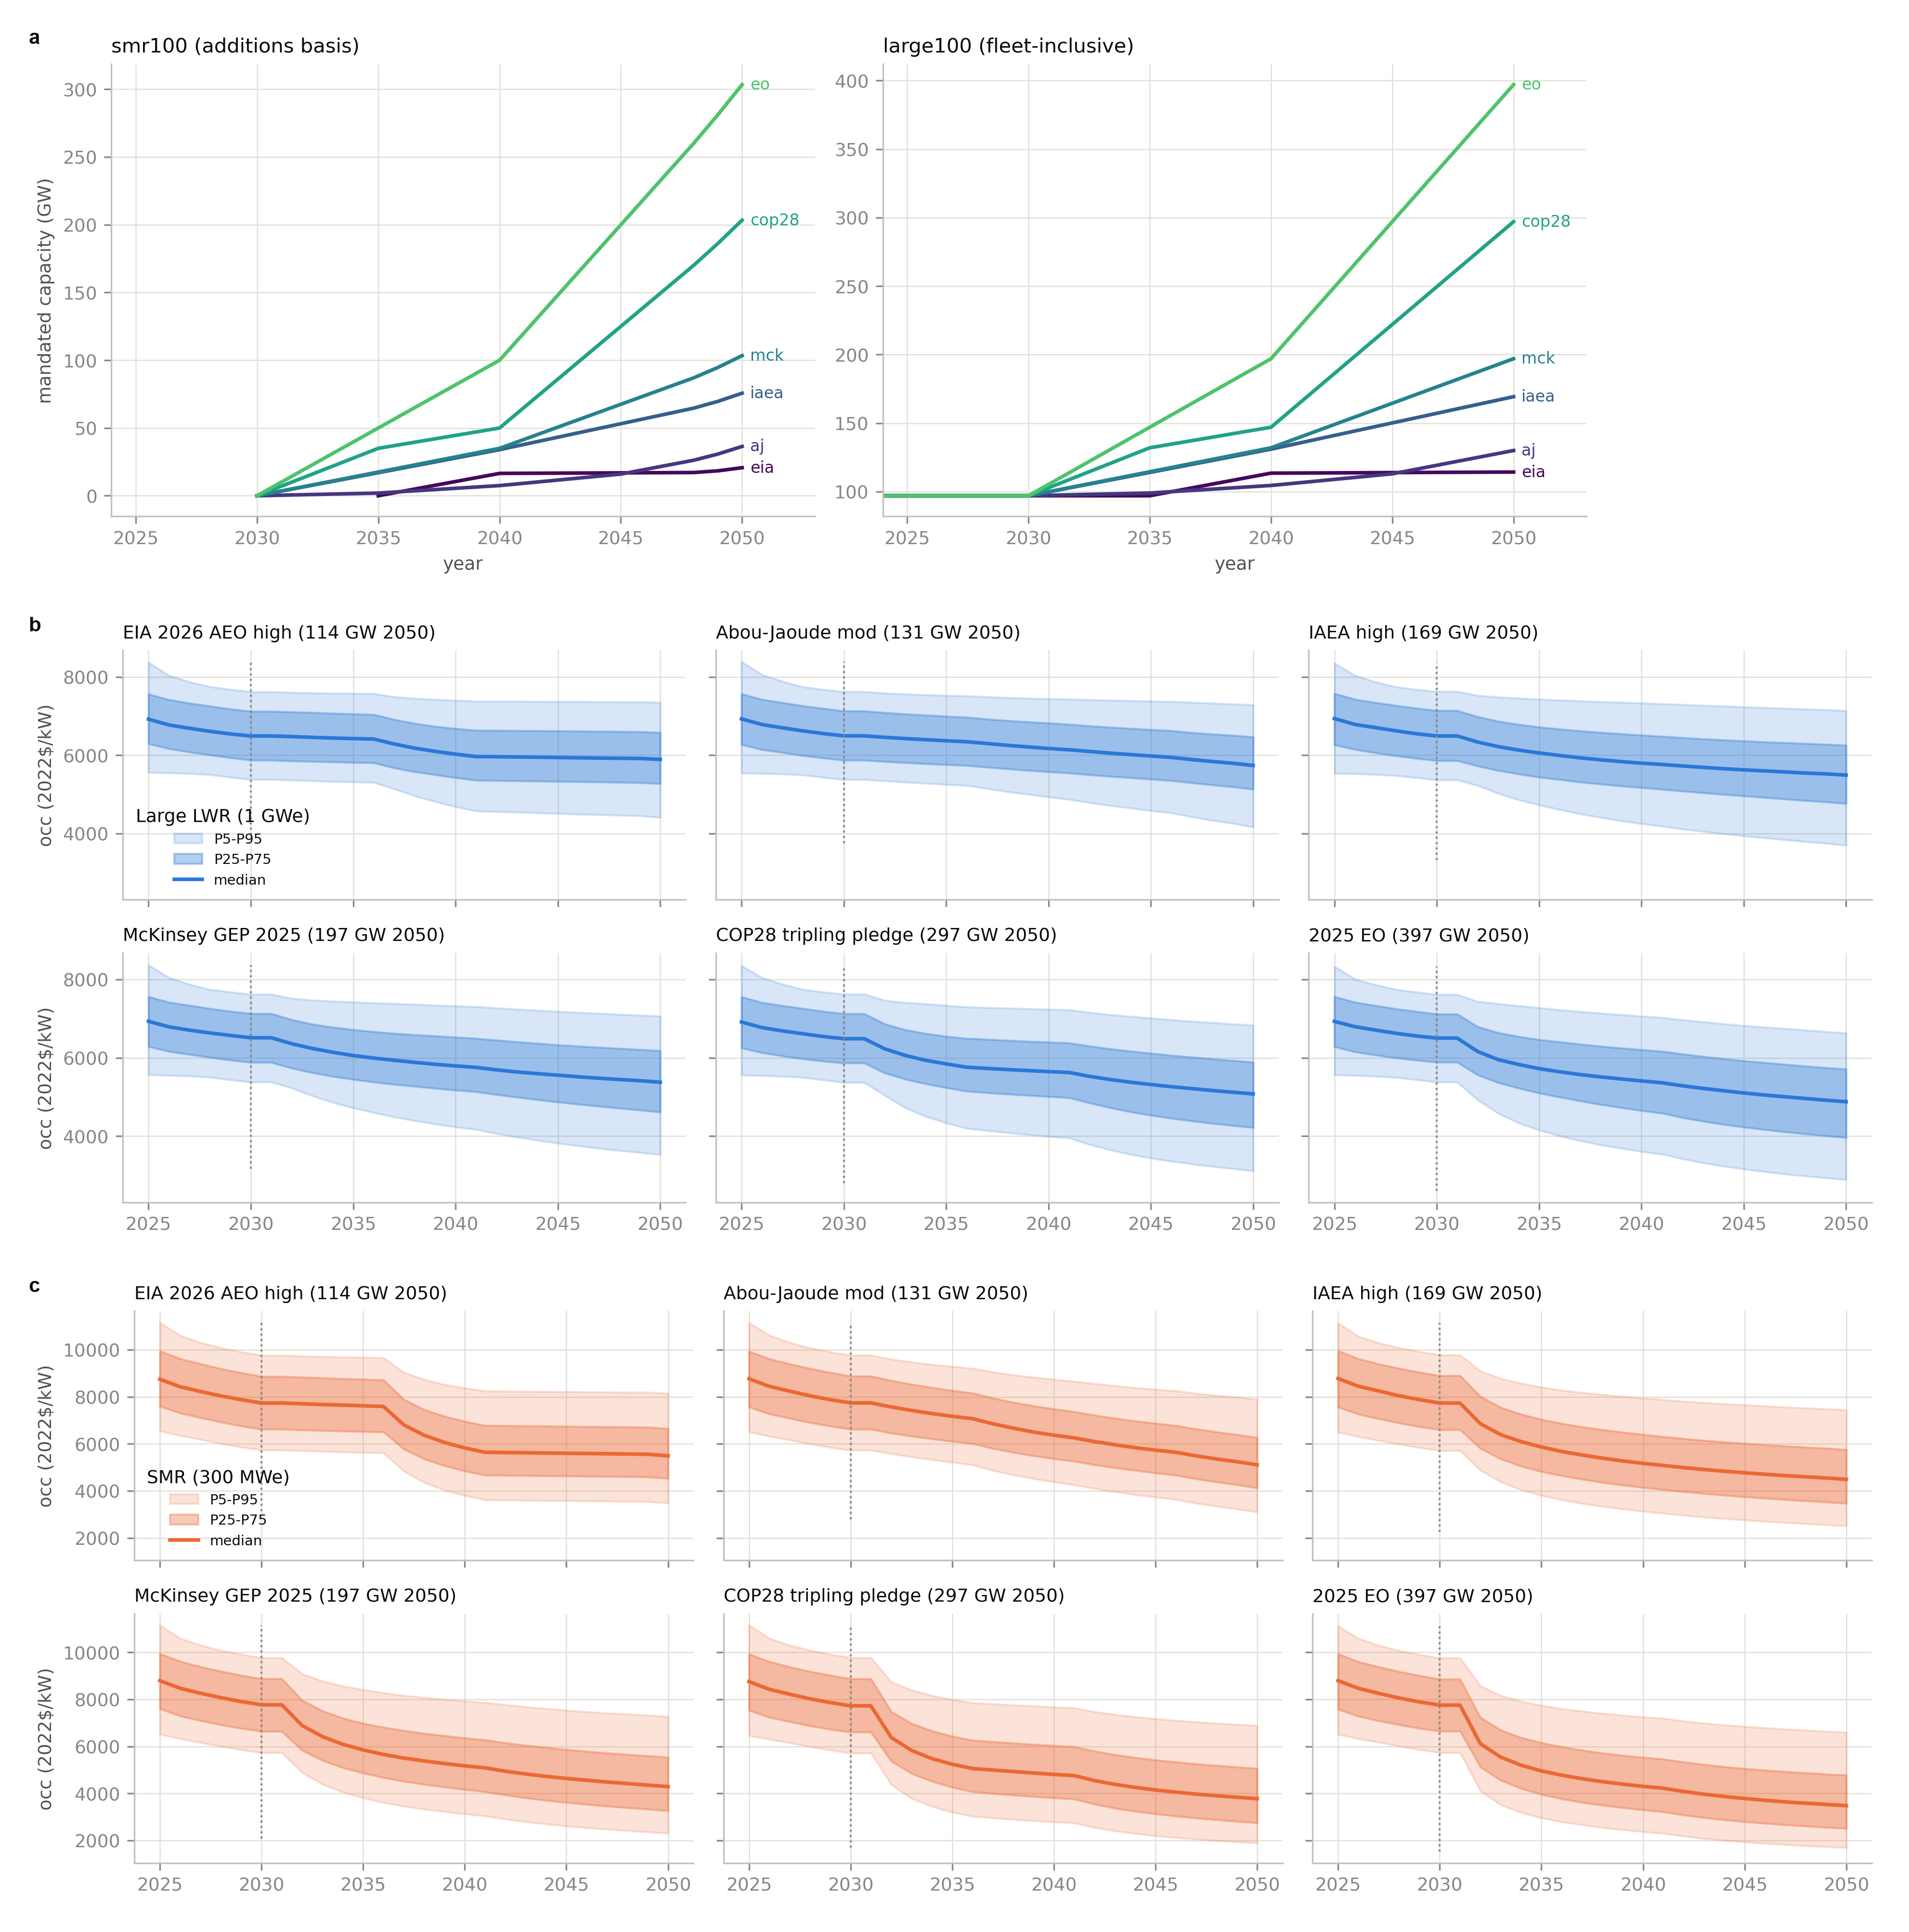

**Sources — edit the figure at its origin, not here:**

- `z-ethan\step3_analysis\figures\f01_mandate_trajectories.png` — generated by `step3_analysis/step3_analysis.ipynb` (cell 10) from `inputs/nuclear_learning/nuclear_cap_trajectory_*.csv` (the mandate files ReEDS reads)
- `z-ethan\mc\figures\occ_fans_large.png` — generated by `mc/mc_cost_trajectories.ipynb` (cell 24) from the in-memory MC results (10,000 joint draws per schedule); percentile export: `mc/exports/mc_occ_percentiles_by_schedule.csv`
- `z-ethan\mc\figures\occ_fans_smr.png` — generated by `mc/mc_cost_trajectories.ipynb` (cell 24) from same MC results, SMR arrays

SMR P50 OCC in 2050, by schedule token:
smr  eia_aeo_high  P50    5494.0
     abou_jaoude   P50    5110.0
     iaea_high     P50    4493.0
     mckinsey      P50    4291.0
     cop28         P50    3779.0
     eo2025        P50    3483.0
2050 P5-P95 span across schedules and techs: 1,693 - 8,151 $/kW

--- draft caption [Fig 2] ---
Deployment schedules and the conditional cost worlds they imply. (a) Six new-nuclear deployment
schedules for the United States, 117-400 GW by 2050, one per provenance class; the paper prices
these schedules and does not rank them. (b, c) Overnight capital cost fans (5th-95th percentile
of 10,000 joint Monte Carlo draws; line = median) conditional on each schedule, for large
reactors (b) and SMR (c). Fans start in 2025 at each draw's backcast first-of-a-kind premium and
pass through the drawn 2030 anchor cost. Median 2050 SMR cost falls from 5,494 $/kW (117 GW
schedule) to 3,483 $/kW (400 GW schedule). Every fan is conditional on its schedule; none is a
proje

In [3]:
P.compose(
    [[S3_FIG / "f01_mandate_trajectories.png"],
     [MC_FIG / "occ_fans_large.png"],
     [MC_FIG / "occ_fans_smr.png"]],
    "Fig2_schedules_and_cost_fans.png",
)
P.source_ref(
    (S3_FIG / "f01_mandate_trajectories.png", "step3_analysis/step3_analysis.ipynb",
     "cell 10", "`inputs/nuclear_learning/nuclear_cap_trajectory_*.csv` (the mandate files ReEDS reads)"),
    (MC_FIG / "occ_fans_large.png", "mc/mc_cost_trajectories.ipynb", "cell 24",
     "the in-memory MC results (10,000 joint draws per schedule); percentile export: `mc/exports/mc_occ_percentiles_by_schedule.csv`"),
    (MC_FIG / "occ_fans_smr.png", "mc/mc_cost_trajectories.ipynb", "cell 24",
     "same MC results, SMR arrays"),
)

# Caption numbers computed from the exported percentiles, so text and data cannot drift.
occ = pd.read_csv(MC_EXP / "mc_occ_percentiles_by_schedule.csv", header=[0, 1, 2], index_col=0)
smr50_2050 = occ.loc[2050, ("smr", slice(None), "P50")]
print(f"SMR P50 OCC in 2050, by schedule token:\n{smr50_2050.round(0).to_string()}")
lo = occ.loc[2050, (slice(None), slice(None), "P5")].min()
hi = occ.loc[2050, (slice(None), slice(None), "P95")].max()
print(f"2050 P5-P95 span across schedules and techs: {lo:,.0f} - {hi:,.0f} $/kW")

P.caption("Fig 2", f'''
Deployment schedules and the conditional cost worlds they imply.
(a) Six new-nuclear deployment schedules for the United States, 117-400 GW by 2050,
one per provenance class; the paper prices these schedules and does not rank them.
(b, c) Overnight capital cost fans (5th-95th percentile of 10,000 joint Monte Carlo
draws; line = median) conditional on each schedule, for large reactors (b) and SMR (c).
Fans start in 2025 at each draw's backcast first-of-a-kind premium and pass through
the drawn 2030 anchor cost. Median 2050 SMR cost falls from {smr50_2050.max():,.0f} $/kW (117 GW schedule) to
{smr50_2050.min():,.0f} $/kW (400 GW schedule). Every fan is conditional on its
schedule; none is a projection.
''')

## Figure 3 — Why all priced cases commit to a 100%-SMR program, now

**What this shows.** Before pricing any schedule, we must choose which
technology carries the program. Panel (a): the probability that SMR is the
cheaper program carrier, across schedules and across the κ dependence grid
(κ is glossed above; each grid cell is a different assumption about how the
two technologies' uncertainties move together). Panel (b): the winning
margin m across the same grid (m > 0 means SMR wins). Panels (c, d): the
cost of hedging instead of committing — the financed-capex paths of the
three program strategies under the McKinsey schedule (c) and the extra
cost of splitting the program 50/50 ("fragmentation penalty", d).
Panel (e): the cost of committing **now** instead of waiting — the
expected value of perfect information (EVPI: the most a decision-maker
would pay to know the drawn world before committing), across the same
dependence grid.

**How to read it.** In panel (a), values above 0.5 mean SMR is the majority
winner in that cell. In panel (d), the distribution sits almost entirely
above zero: splitting the program is not a free hedge, because it splits
the learning.

**Key results.** SMR is the cheaper carrier with probability 0.82–0.89 under
the tightest coupling, and stays the majority winner in every primary κ
cell. The worst cell gives 0.509. That cell is the decoupled-anchor probe
(see the glossary): the learning rates stay coupled, but each technology
draws its starting cost independently — not the κ = 0 cell, which
decouples both. Splitting 50/50 costs a median 16.7% of
program cost. A per-draw optimizer over mixed programs beats the pure
programs in only 10 of 60,000 draws, and by at most 0.51%.

Committing now, rather than waiting to learn which world we are in,
forfeits little (panel e): EVPI is 0.57–0.66% of expected program cost at
κ = 1, rising to 2.3–4.6% fully decoupled and up to about 6.0% at the
decoupled-anchor probe (learning rates stay fully coupled, but each
technology draws its 2030 starting cost independently — not κ = 0, which
decouples both). A perfect-information switch of technology in 2036
recovers at most 0.12–0.66% at κ = 1. These are perfect-information
upper bounds; no noisy-signal tier was built.

**Fair-warning results, stated with equal prominence.** When large wins in
decoupled worlds, its margins can reach about 30%. And a stress test that
inflates SMR costs by 1.5× (an optimism-bias stress) breaks the claim.
The commitment is majority-optimal, not certain.

composed -> z-ethan\paper_figures\figures\Fig3_technology_choice.png  (3972x4118 px)


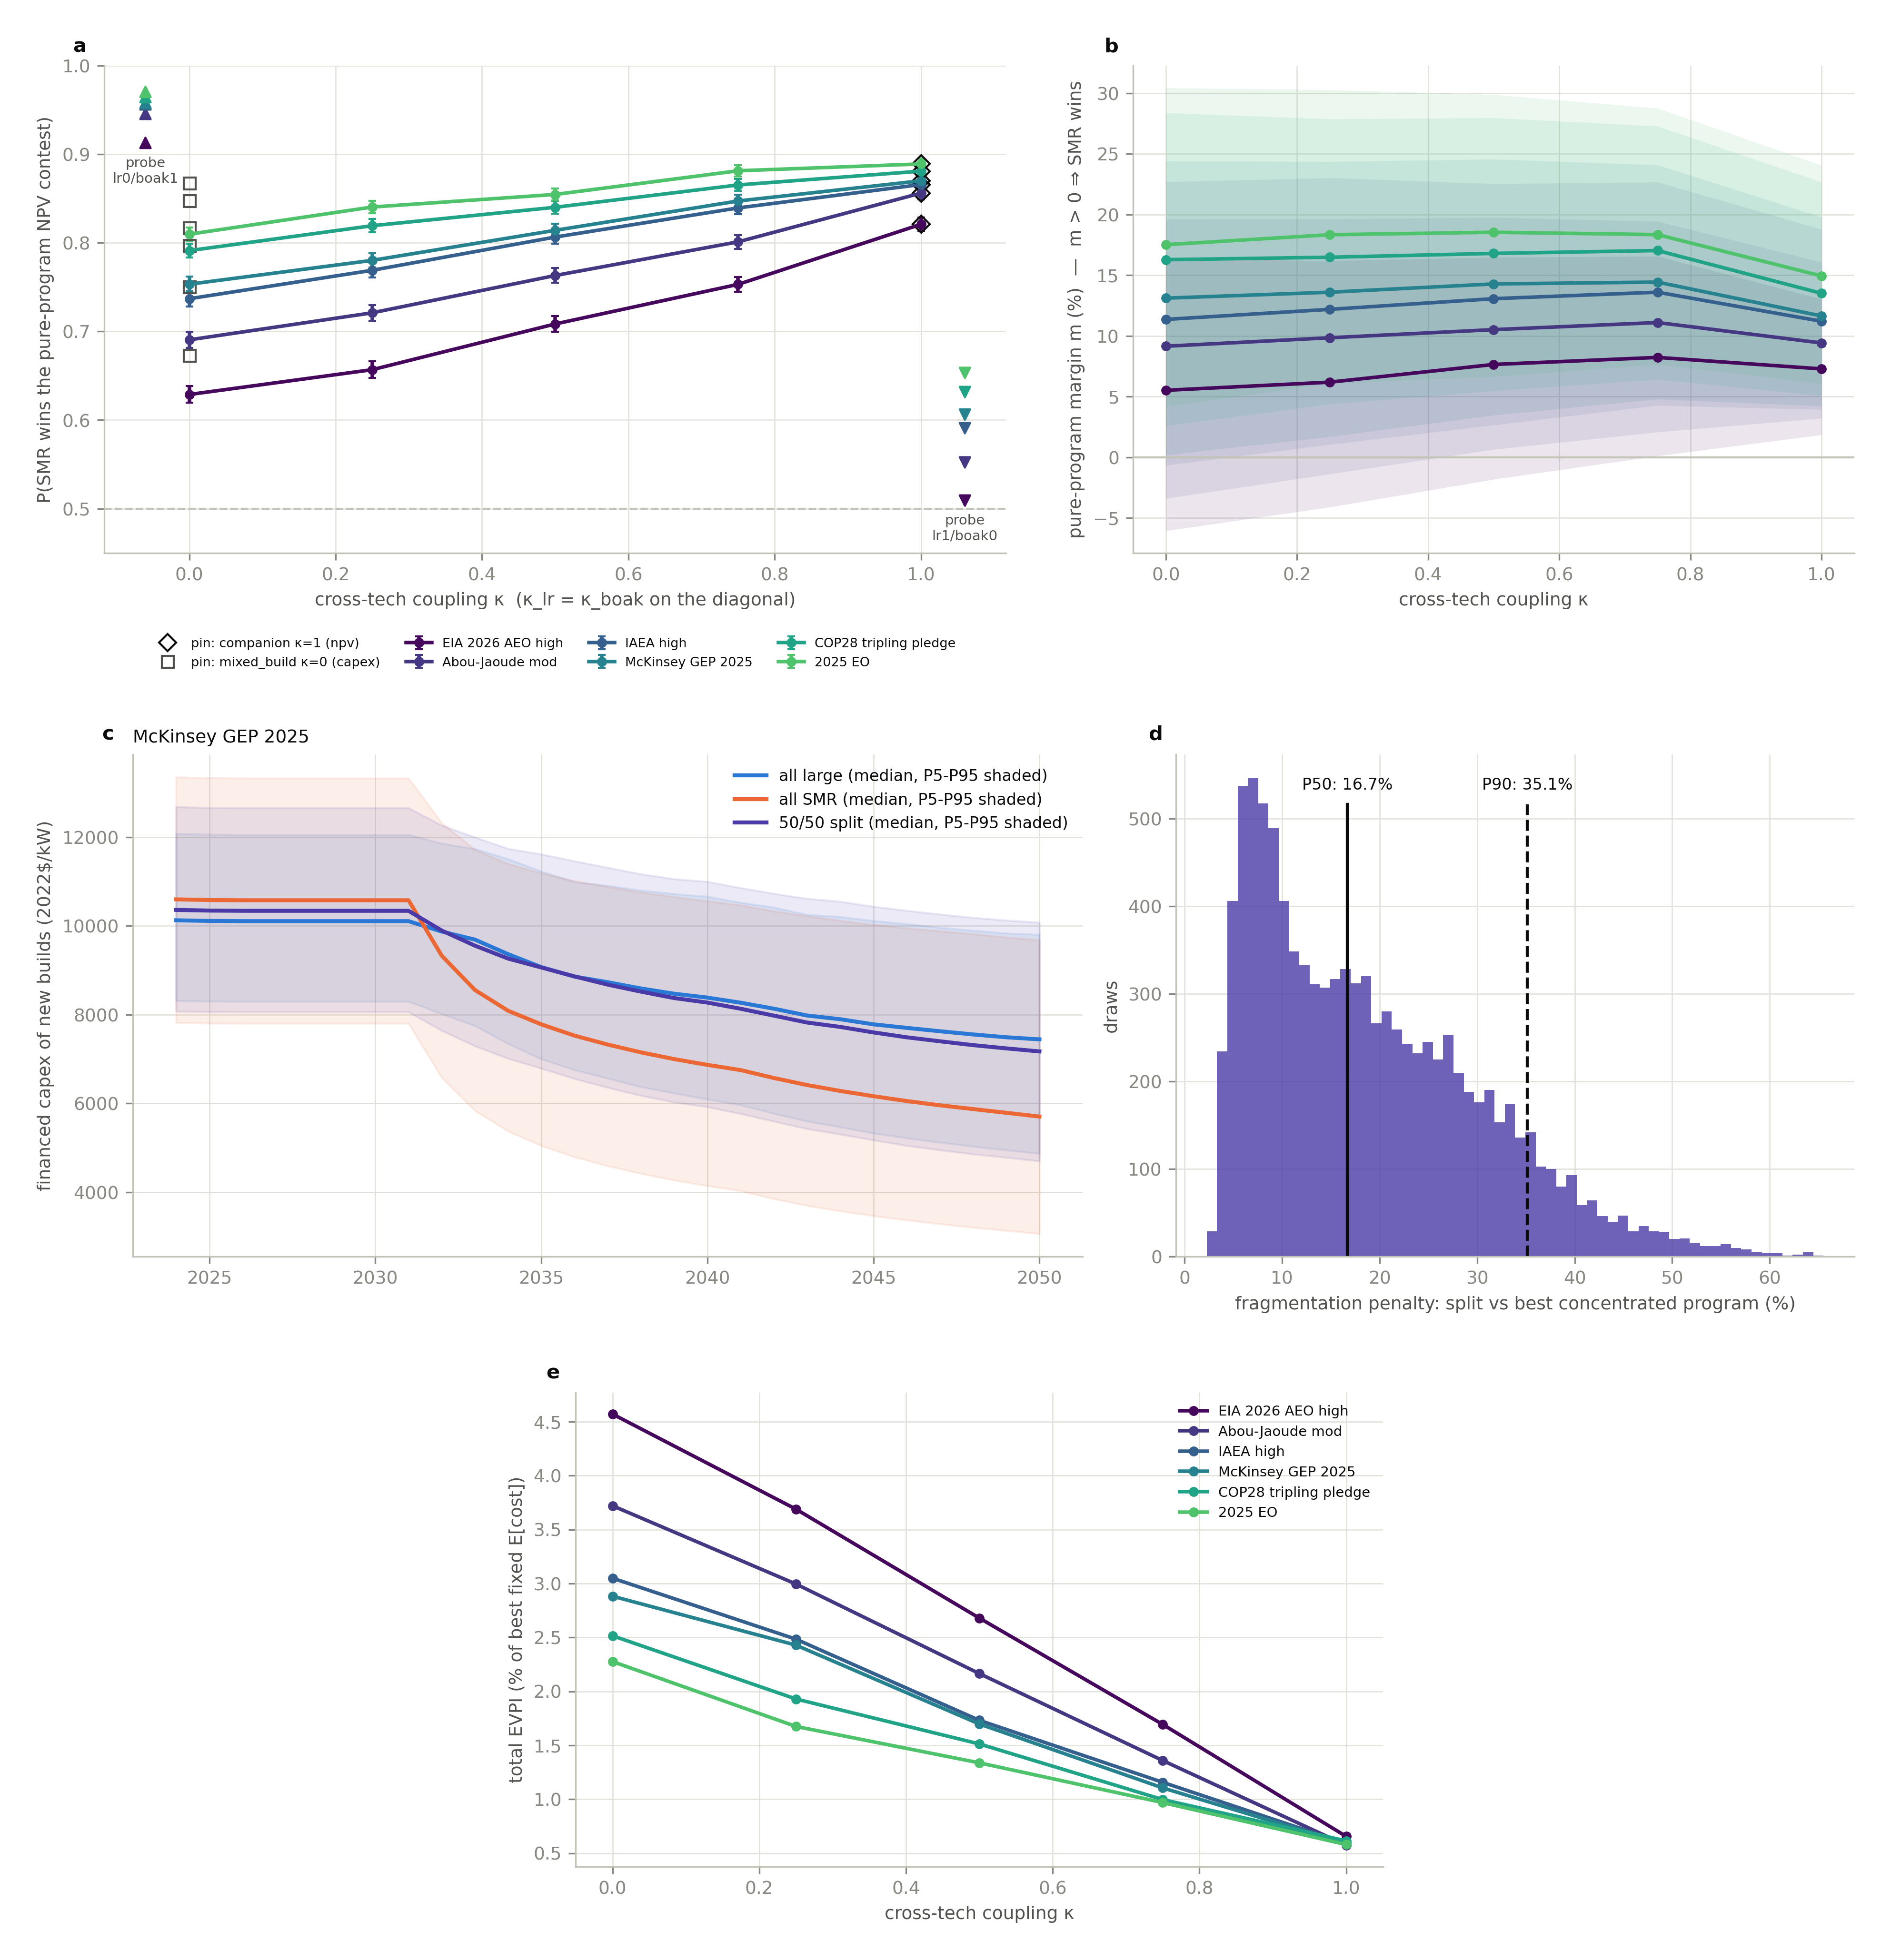

**Sources — edit the figure at its origin, not here:**

- `z-ethan\mc\figures\tc_robustness_map.png` — generated by `mc/tech_comparison.ipynb` (cell 18) from `mc/exports/mc_perdraw.npz` + the κ-grid per-draw exports; table: `mc/exports/tech_comparison/robustness_map.csv`
- `z-ethan\mc\figures\fragmentation_penalty.png` — generated by `mc/mc_cost_trajectories.ipynb` (cell 40) from in-memory MC worlds for the McKinsey schedule (the fragmentation experiment)
- `z-ethan\mc\figures\tc_evpi_inset.png` — generated by `mc/tech_comparison.ipynb` (cell T8b (added 2026-08-21)) from `mc/exports/tech_comparison/evpi_total.csv` (the full total+partial figure stays in the SI, SF7)

P(SMR cheaper), primary κ cells: min 0.503 (incl. probes), comonotone range 0.51-0.89

--- draft caption [Fig 3] ---
The technology choice, and the cost of committing now. (a) Probability that a 100%-SMR program
is cheaper than a 100%-large program, across schedules and across the dependence grid (kappa =
how strongly the two technologies' cost uncertainties move together). SMR is the majority winner
in every primary cell; the minimum is 0.509 at the decoupled-anchor probe (learning rates
coupled, 2030 starting costs drawn independently — unlike kappa = 0, which decouples both). (b)
The winning margin m across the same grid (m > 0 = SMR wins; median and quantile fans). (c)
Financed capex of the three program strategies under the McKinsey schedule (medians, P5-P95
bands). (d) Fragmentation penalty: the extra program cost of the 50/50 split, median 16.7% —
splitting the program splits the learning. (e) Expected value of perfect information: committing
now instead of waiting forfeits 0.57

In [4]:
P.compose(
    [[MC_FIG / "tc_robustness_map.png"],
     [MC_FIG / "fragmentation_penalty.png"],
     [MC_FIG / "tc_evpi_inset.png"]],
    "Fig3_technology_choice.png",
    letters="",  # all sources carry their final letters (a,b / c,d / e)
    center=True,  # the EVPI inset row is narrower; do not leave a corner blank
)
P.source_ref(
    (MC_FIG / "tc_robustness_map.png", "mc/tech_comparison.ipynb", "cell 18",
     "`mc/exports/mc_perdraw.npz` + the κ-grid per-draw exports; table: `mc/exports/tech_comparison/robustness_map.csv`"),
    (MC_FIG / "fragmentation_penalty.png", "mc/mc_cost_trajectories.ipynb", "cell 40",
     "in-memory MC worlds for the McKinsey schedule (the fragmentation experiment)"),
    (MC_FIG / "tc_evpi_inset.png", "mc/tech_comparison.ipynb", "cell T8b (added 2026-08-21)",
     "`mc/exports/tech_comparison/evpi_total.csv` (the full total+partial figure stays in the SI, SF7)"),
)

rm = pd.read_csv(MC_EXP / "tech_comparison" / "robustness_map.csv")
prim = rm[rm["kind"] == "primary"]
print(f"P(SMR cheaper), primary κ cells: min {rm['P_smr'].min():.3f} "
      f"(incl. probes), comonotone range {prim[prim['kappa_lr'] == 1.0]['P_smr'].min():.2f}"
      f"-{prim[prim['kappa_lr'] == 1.0]['P_smr'].max():.2f}")

P.caption("Fig 3", '''
The technology choice, and the cost of committing now. (a) Probability that a 100%-SMR
program is cheaper than a 100%-large program, across schedules and across the dependence
grid (kappa = how strongly the two technologies' cost uncertainties move together). SMR
is the majority winner in every primary cell; the minimum is 0.509 at the
decoupled-anchor probe (learning rates coupled, 2030 starting costs drawn independently
— unlike kappa = 0, which decouples both). (b) The winning
margin m across the same grid (m > 0 = SMR wins; median and quantile fans).
(c) Financed capex of the three program strategies under the McKinsey schedule
(medians, P5-P95 bands). (d) Fragmentation penalty: the extra program cost of the
50/50 split, median 16.7% — splitting the program splits the learning. (e) Expected
value of perfect information: committing now instead of waiting forfeits 0.57-0.66% of
expected program cost in coherent (kappa = 1) worlds, up to ~6.0% at the
decoupled-anchor probe — a perfect-information upper bound. The commitment
is majority-optimal, not certain: large can win by ~30% in decoupled worlds, and a
1.5x SMR optimism-bias stress breaks the claim.
''')

## Figure 4 — The required subsidy is a bridge — in cheap worlds

**What this shows.** The paper's central object: the mandate's shadow
price — the yearly rental price, per kW of mandated capacity, that makes
each schedule worth building (see glossary). Panel (a): the shadow price
over time for each schedule, in cheap (P5), median (P50), and expensive
(P95) cost worlds, with the large-reactor comparator overlaid at P50.
Panel (b): the same shadow prices divided by their own peak, so every
case starts at 1 and we can compare shapes.

**How to read it.** A "bridge" subsidy should decay: high at first, near
zero once the fleet has walked down the learning curve. Panel (b) tests
exactly that.

**Key results.**
- The shadow price is monotone in the cost world: expensive worlds need
  more in every year, with no crossings (visually apparent in the fans;
  quantified in Methods). Mean binding shadow prices run 70–201 (P5),
  314–390 (P50), and 610–698 (P95) in 2024\$/kW-yr; the single peak is 894
  (EO schedule, P95 world, 2031).
- In cheap worlds the bridge comes down: end-of-horizon shadow prices are
  3–19% of peak. Median worlds are mixed. **In P95 worlds the subsidy does
  not come down: 66–84% of peak in 2050, and no P95 case falls below half
  its peak by 2050.** Under slow learning the subsidy is not a bridge but
  a standing commitment. We give this adverse result the same prominence
  as the decay result.
- The cross-section of the mean binding shadow price against schedule
  ambition moved to the SI in the 08-20 restructure (SF-ambition, `f06`).

composed -> z-ethan\paper_figures\figures\Fig4_shadow_price.png  (3822x3238 px)


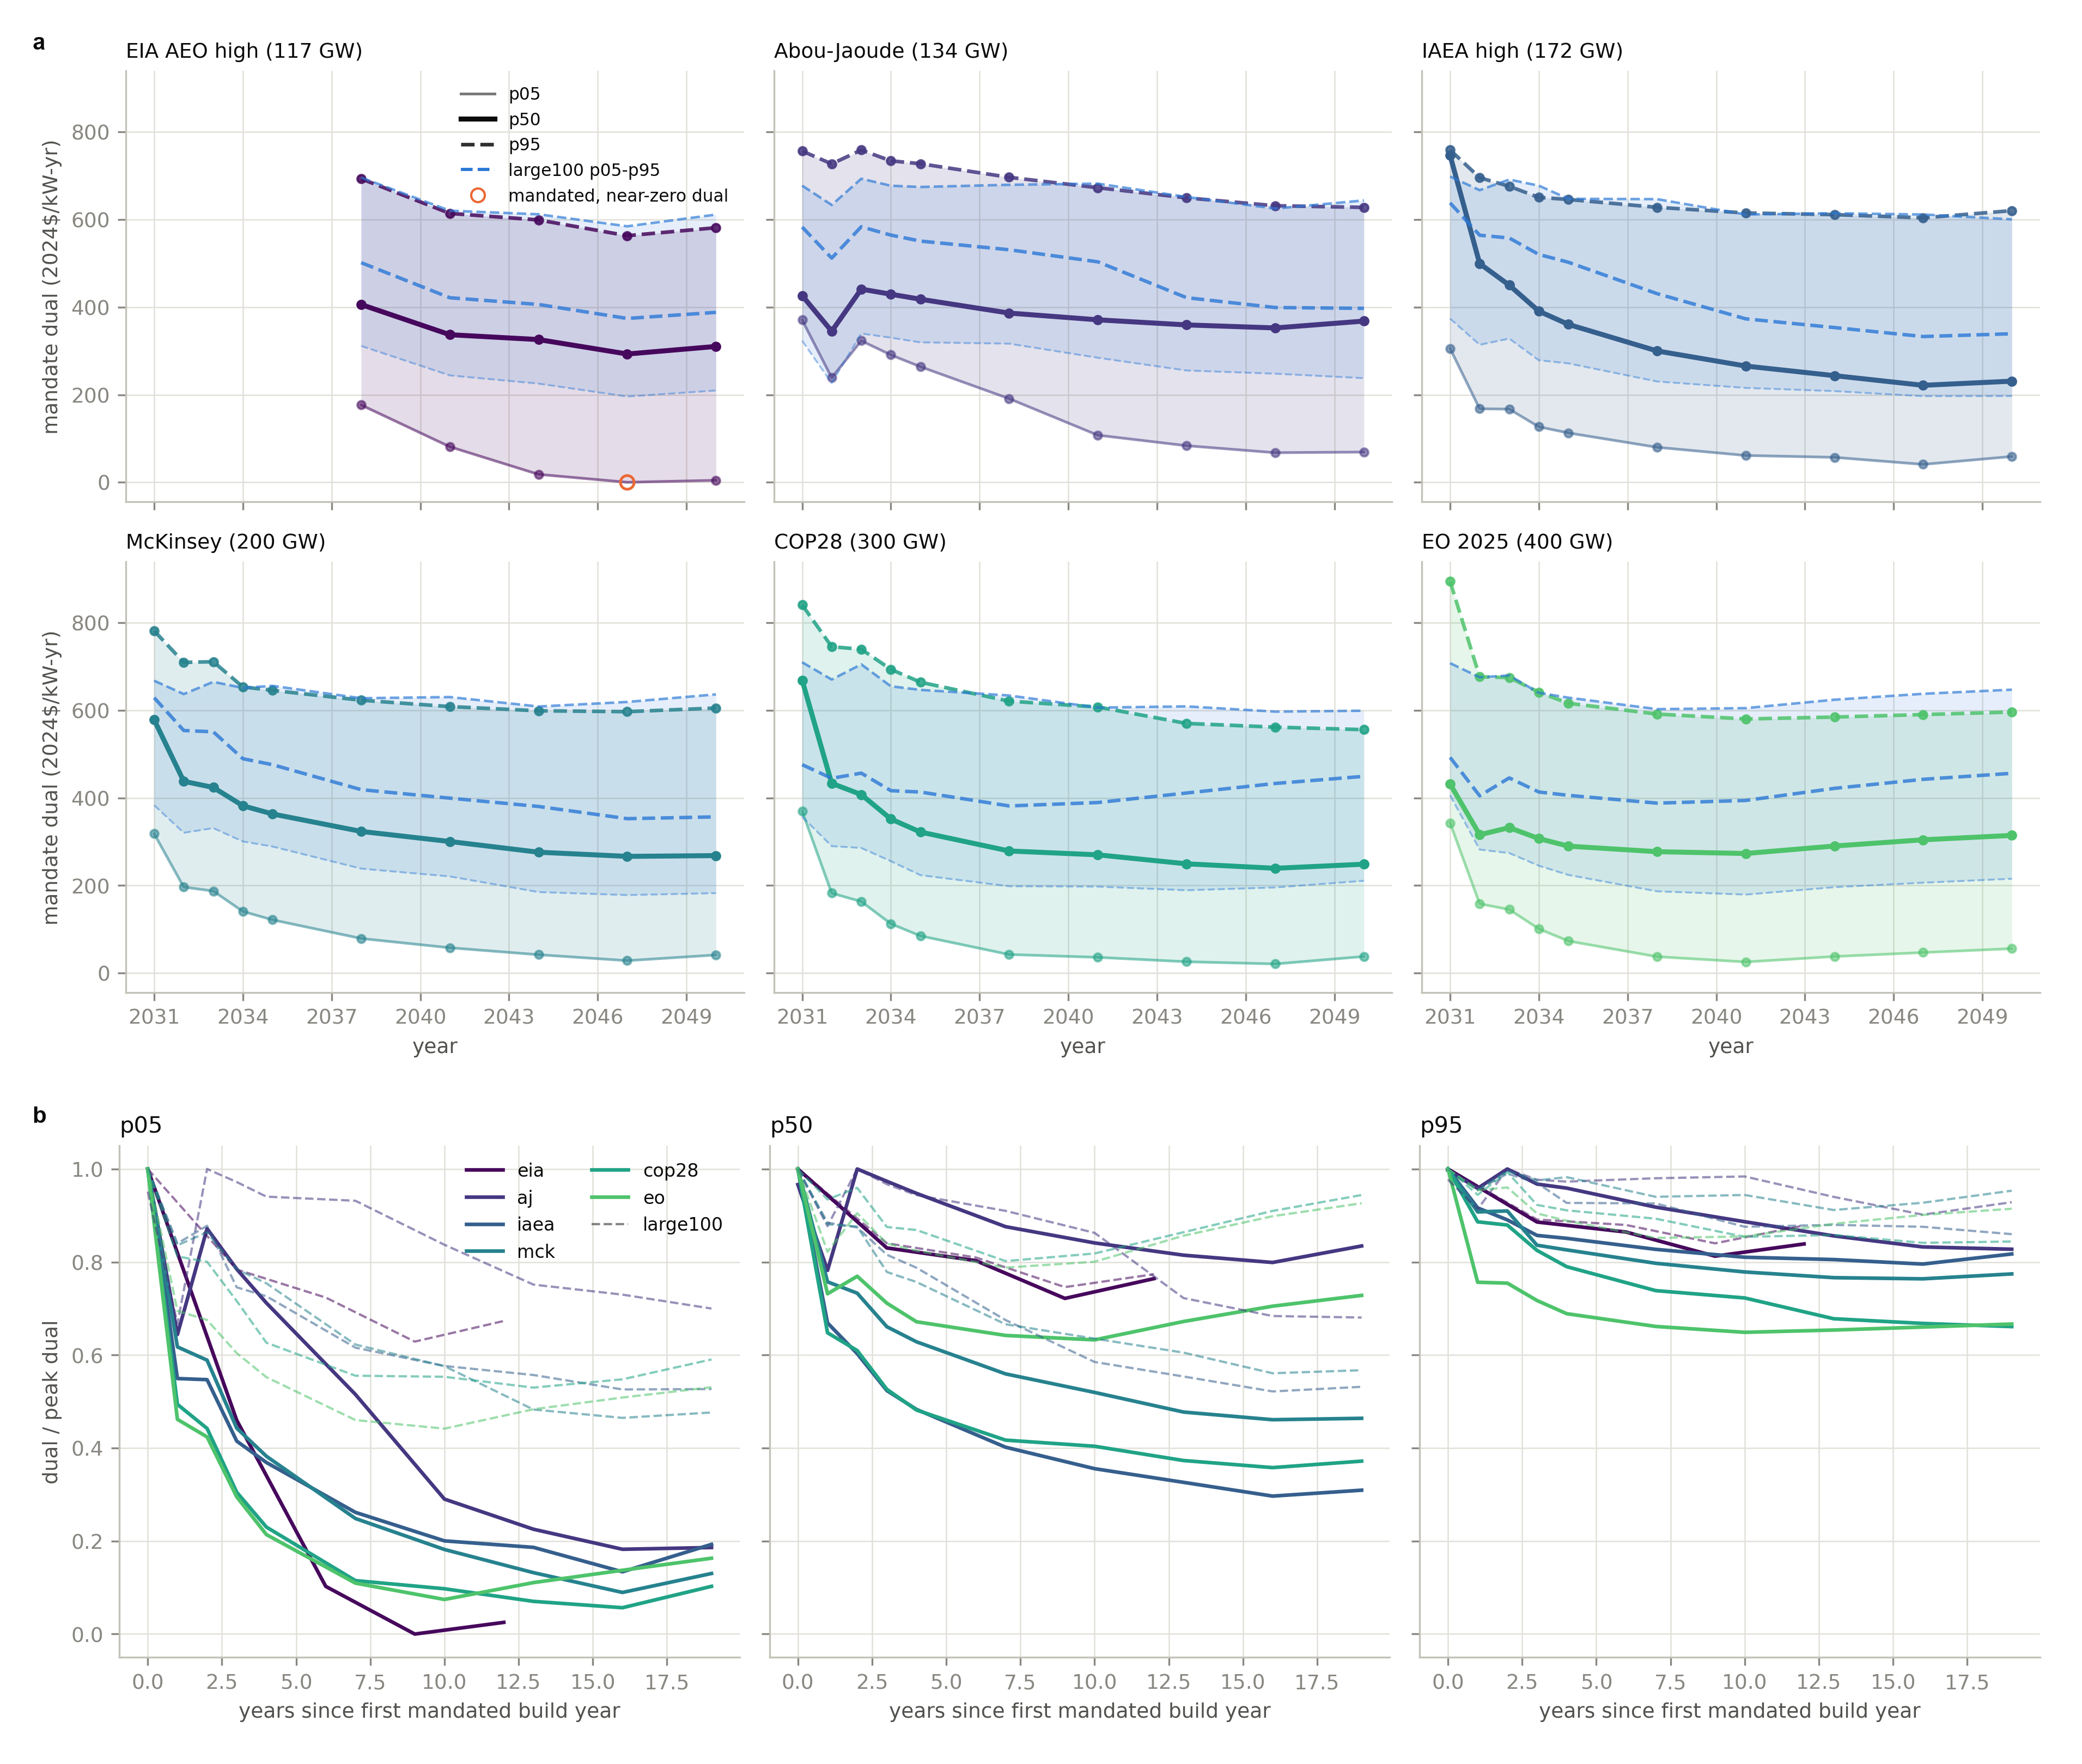

**Sources — edit the figure at its origin, not here:**

- `z-ethan\step3_analysis\figures\f04_dual_fans.png` — generated by `step3_analysis/step3_analysis.ipynb` (cell 18) from `step3_checks/exports/duals_by_year.csv` (+ step4 checks for the large100 overlay)
- `z-ethan\step3_analysis\figures\f07_dual_shape_normalized.png` — generated by `step3_analysis/step3_analysis.ipynb` (cell 26) from same shadow prices, normalized by each case's peak

p05: mean binding shadow price 70-201 2024$/kW-yr
p50: mean binding shadow price 314-390 2024$/kW-yr
p95: mean binding shadow price 610-698 2024$/kW-yr
peak shadow price: 894 (smr100_eo_p95, 2031)
p95 end/peak: 0.66-0.84; p95 cases below half-peak by 2050: 0 of 6

--- draft caption [Fig 4] ---
The required subsidy and its bridge shape. (a) The mandate's shadow price — the yearly rental
price per kW of mandated capacity (2024$) — by solve year, for each schedule in cheap (P5),
median (P50), and expensive (P95) cost worlds; large-reactor P50 comparators overlaid. Shadow
prices rise with the cost world in every year, with no crossings, peaking at 894 $/kW-yr
(smr100_eo_p95, 2031). (b) Shadow prices normalized by their own peak: cheap worlds decay to
3-19% of peak; no P95 case reaches half its peak by 2050 — under slow learning the subsidy is a
standing commitment, not a bridge.


In [5]:
P.compose(
    [[S3_FIG / "f04_dual_fans.png"],
     [S3_FIG / "f07_dual_shape_normalized.png"]],
    "Fig4_shadow_price.png",
    center=True,  # row widths differ; do not leave a blank corner
)
P.source_ref(
    (S3_FIG / "f04_dual_fans.png", "step3_analysis/step3_analysis.ipynb", "cell 18",
     "`step3_checks/exports/duals_by_year.csv` (+ step4 checks for the large100 overlay)"),
    (S3_FIG / "f07_dual_shape_normalized.png", "step3_analysis/step3_analysis.ipynb", "cell 26",
     "same shadow prices, normalized by each case's peak"),
)

t03 = pd.read_csv(S3_EXP / "t03_dual_summary.csv")
t04 = pd.read_csv(S3_EXP / "t04_bridge_metrics.csv")
smr = t03[t03["case"].str.startswith("smr100")]
for pct in ["p05", "p50", "p95"]:
    sel = smr[smr["case"].str.endswith(pct)]
    print(f"{pct}: mean binding shadow price {sel['mean_binding_dual_2024_kWyr'].min():.0f}"
          f"-{sel['mean_binding_dual_2024_kWyr'].max():.0f} 2024$/kW-yr")
pk = t03.loc[t03["peak_dual_2024_kWyr"].idxmax()]
print(f"peak shadow price: {pk['peak_dual_2024_kWyr']:.0f} ({pk['case']}, {int(pk['peak_year'])})")
p95 = t04[t04["case"].str.startswith("smr100") & t04["case"].str.endswith("p95")]
n_below = int((p95["first_year_below_half_peak"] <= 2050).sum())
print(f"p95 end/peak: {p95['end_over_peak'].min():.2f}-{p95['end_over_peak'].max():.2f}; "
      f"p95 cases below half-peak by 2050: {n_below} of {len(p95)}")

P.caption("Fig 4", f'''
The required subsidy and its bridge shape. (a) The mandate's shadow price — the yearly
rental price per kW of mandated capacity (2024$) — by solve year, for each schedule in
cheap (P5), median (P50), and expensive (P95) cost worlds; large-reactor P50 comparators
overlaid. Shadow prices rise with the cost world in every year, with no crossings,
peaking at {pk['peak_dual_2024_kWyr']:.0f} $/kW-yr ({pk['case']}, {int(pk['peak_year'])}).
(b) Shadow prices normalized by their own peak: cheap worlds decay to 3-19% of peak; no
P95 case reaches half its peak by 2050 — under slow learning the subsidy is a standing
commitment, not a bridge.
''')

## Figure 5 — Required tax-credit rates and the cost of voluntary delivery

Recomposed 2026-08-24 (team review, option B): the f16 menu panel moved
to SF31 and the closed-loop delivery panel to SF23 — delivery validates
the funding claim, it is not a standalone finding. Fig 5 is now three
panels, all on the voluntary instruments only, and panels (b) and (c)
are linear. Panel (c) — the rate–deployment cliff — was promoted the
same day (an explicit one-exhibit reversal of the delivery-to-SI
demotion: the cliff is a rate result, not a validation exhibit; the
validation exhibits stay in SF23).

**What this shows.** The shadow price is a model price. This figure
translates it into the actual US policy instrument, prices the
translation, and shows what under-paying it buys. Panel (a): the
required investment tax
credit (ITC) rate, by year and case,
on the **model credit convention** (i_model: the fin_mult inversion plus
the 10% monetization haircut; the placed-in-service overnight-cost-only
conversion i_pis = i_model x ccmult is exported per year). The shaded band
marks the current 48E credit range (30–50%); the line at 100% marks where
an ITC alone cannot deliver. Panel (b): the **cost of buying the same
deployment voluntarily** — the uniform percentage credit's net-of-tax
present-value cost as a multiple of the minimum-cost floor (a flat
dollar-per-MW payment at commissioning with frictionless monetization),
by schedule, ordered by 2050 ambition (f17). Panel (c): the
**rate–deployment cliff** (j06) — new-nuclear 2050 capacity against the
credit rate on the same basis as panel (a), combining the flat-credit
anchors, the 24-run minus-probe ladders, and the headline schedule
points; new nuclear equals SMR capacity exactly because large-reactor
additions are credit-invariant in every run (the zero-substitution
result).

**How to read it.** In panel (a), rates are per-region requirements; the
headline is the maximum building region. Where a line sits above the 48E
band, current law is not enough. Where it crosses 100%, no credit
percentage can close the gap. In panel (b), distance above 1.0 is money
the instrument wastes relative to the floor: the solid line is the floor,
the dotted line is the floor with only the 10% monetization haircut
applied (x1.111), markers are the median (P50) cost world, and whiskers
span P5–P95. In panel (c), the shaded band is the same 48E range as in
panel (a): the entire current-law range sits in the flat tail of the
response, and the cliff starts a few points past its right edge.

**Key results.** Median-world required rates average 0.59–0.74 across
schedules — 2.0–2.5 times the current base credit. Expensive worlds need
2.7–3.1 times; on the headline convention only 5 of 329 rated case-years
exceed 100% (the i_pis conversion exceeds 100% in 82). The uniform
percentage credit costs 1.17–1.25x the floor in every case — the ~10%
monetization haircut plus a 5–13% uniform-rate oversubsidy, two frictions
and nothing else — and the premium does not grow with ambition, cost
world, or technology; the unleveraged cash grant sits at 1.04x. The
mandate and commitment-bound benchmarks are context, not results
(demotion ruling 08-20 — the paper reports the floor and the ITC): the
full menu with the mandate's cut-hold band (0.23–0.90x the floor for the
SMR program, 0.83–5.65x for the large-reactor arm where the pre-existing
fleet's rent of 141–675 B$ PV dominates) is SF31. The mandate prices the
same deployment by coercion: the shortfall against the builders'
requirement lands on early-vintage capital, a first-cohort transfer
rather than a repeatable voluntary price.

**The cliff (panel c) and the delivery validation (SI).** The response
to the rate is a cliff, not a slope: zero SMR at a flat 30% credit,
9.8 GW at 50% — the entire current-law 48E range buys almost nothing —
against 27–381 GW at the schedule rates. The 24-run minus probe brackets
the delivery-minimal rate within five points below the headline, and
below the boundary the learning feed-back amplifies the shortfall
instead of cushioning it (solid fbC curves under the dashed fbB curves
on the low side, over them at the headline). The closed-loop delivery
validation stays in the SI: the credit alone reproduces the mandated
deployment in 5 of 6 median worlds (EIA partial: a delayed start under
myopic lagged costs, recovering past its trajectory by 2050) and
over-delivers (1.3–2.7x), never under (SF23, ST9, SN6).

The two legal rate-level inputs are resolved (2026-08-20, open item 7):
the monetization haircut defaults to 10% (bank tax-equity partnership)
with an exact x0.947 conversion to the 5% best-transfer-market variant,
and depreciation is 15-year MACRS throughout (hypothetical-policy
convention; no current-law conversion reported). The haircut range moves
every rate in panel (a) by an exact factor; nothing changes the shape.
Per-case ranges: step3 t20 export; legal detail:
`ITC calculation procedure.md`.

composed -> z-ethan\paper_figures\figures\Fig5_required_itc_and_menu.png  (3936x3300 px)


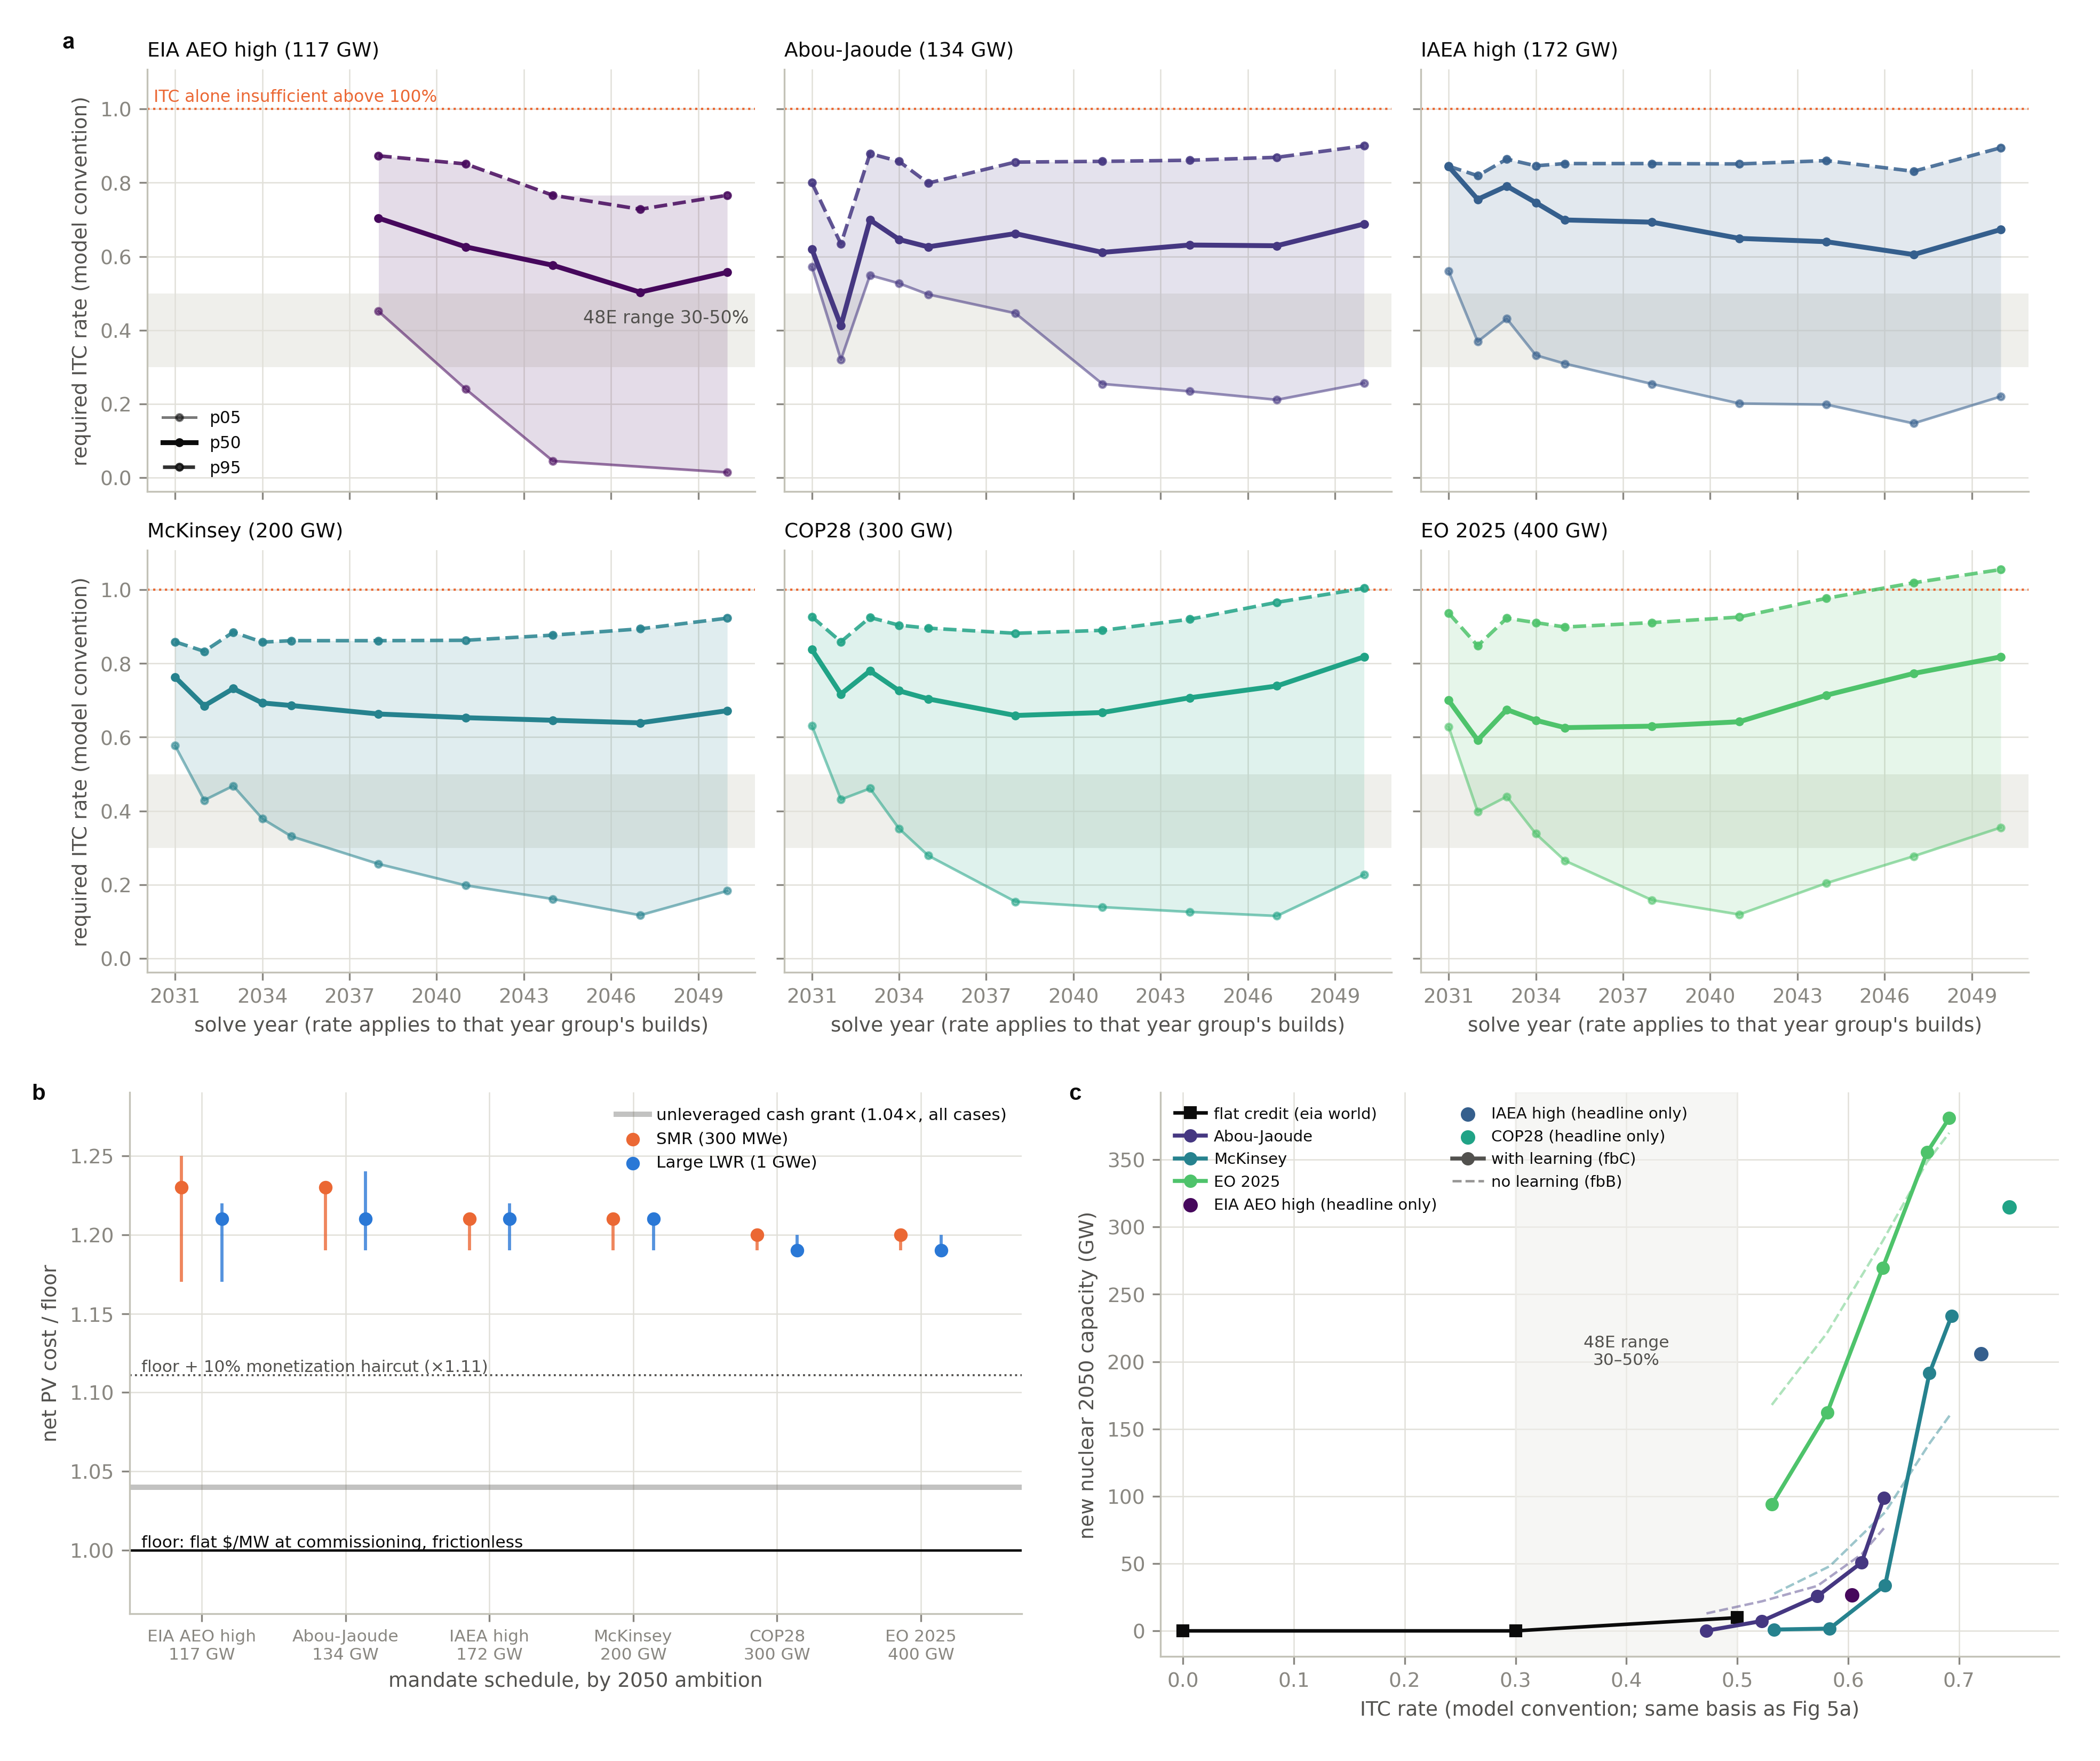

**Sources — edit the figure at its origin, not here:**

- `z-ethan\step3_analysis\figures\f13_required_itc.png` — generated by `step3_analysis/step3_analysis.ipynb` (cell 40) from `step3_analysis/exports/t09_required_itc.csv` (model convention, regenerated 2026-08-18)
- `z-ethan\step3_analysis\figures\f17_itc_vs_ambition.png` — generated by `step3_analysis/step3_analysis.ipynb` (cell f17cd001) from `t18_instrument_menu.csv` (voluntary instruments only; option B panel, 2026-08-24)
- `z-ethan\itcfbm_analysis\figures\j06_new_nuclear_cliff.png` — generated by `itcfbm_analysis/itcfbm_analysis.ipynb` (cell j06cd001) from `r04_rate_deployment.csv` (statutory basis, new nuclear only; promoted 2026-08-24)

p50 required rate (model convention), schedule averages: 0.59-0.74 (= 2.0x-2.5x the 30% base 48E credit)
case-years over 100%: 5 of 329 on the model convention; 82 on the placed-in-service OCC-only conversion
uniform ITC vs floor: 1.17-1.25x (haircut x1.111 + oversubsidy 5-13%); cash grant 1.04x

--- draft caption [Fig 5] ---
Required ITC rates and the cost of voluntary delivery. (a) The required investment-tax-credit
rate by solve year on the model credit convention (fin_mult inversion + 10% monetization
haircut; the placed-in-service overnight-cost-only conversion is exported per year), P50 lines
with P5-P95 whiskers; band = current 48E range (30-50%), line = 100%. Median-world schedule
averages run 0.59-0.74 (2.0-2.5x the base credit); 5 of 329 rated case-years exceed 100% (82 on
the placed-in-service conversion). (b) The net-of-tax present-value cost of a uniform percentage
credit, as a multiple of the minimum-cost floor — a flat dollar-per-MW payment at commissioning
with friction

In [6]:
P.compose(
    [[S3_FIG / "f13_required_itc.png"],
     [S3_FIG / "f17_itc_vs_ambition.png", ITCFBM_FIG / "j06_new_nuclear_cliff.png"]],
    "Fig5_required_itc_and_menu.png",
    letters="abc",
    center=True,  # row widths differ; do not leave a blank corner
)
P.source_ref(
    (S3_FIG / "f13_required_itc.png", "step3_analysis/step3_analysis.ipynb", "cell 40",
     "`step3_analysis/exports/t09_required_itc.csv` (model convention, regenerated 2026-08-18)"),
    (S3_FIG / "f17_itc_vs_ambition.png", "step3_analysis/step3_analysis.ipynb", "cell f17cd001",
     "`t18_instrument_menu.csv` (voluntary instruments only; option B panel, 2026-08-24)"),
    (ITCFBM_FIG / "j06_new_nuclear_cliff.png", "itcfbm_analysis/itcfbm_analysis.ipynb",
     "cell j06cd001", "`r04_rate_deployment.csv` (statutory basis, new nuclear only; "
     "promoted 2026-08-24)"),
)

t09 = pd.read_csv(S3_EXP / "t09_required_itc.csv")
r = t09[t09["status"] == "rate"]
smr_r = r[r["case"].str.startswith("smr100")]
p50 = smr_r[smr_r["case"].str.endswith("p50")].groupby("case")["i_model_headline"].mean()
print(f"p50 required rate (model convention), schedule averages: {p50.min():.2f}-{p50.max():.2f} "
      f"(= {p50.min()/0.30:.1f}x-{p50.max()/0.30:.1f}x the 30% base 48E credit)")
ded = r[~r["case"].str.endswith("_eq")]
n100 = int((ded["i_model_headline"] > 1.0).sum())
n100p = int((ded["i_pis_headline"] > 1.0).sum())
print(f"case-years over 100%: {n100} of {len(ded)} on the model convention; "
      f"{n100p} on the placed-in-service OCC-only conversion")

t18 = pd.read_csv(S3_EXP / "t18_instrument_menu.csv")
m18 = t18[~t18["case"].str.endswith("_eq")]
hair = float(m18["dpmw_haircut"].iloc[0])
ov_lo = (m18["uniform_itc"].min() / hair - 1) * 100
ov_hi = (m18["uniform_itc"].max() / hair - 1) * 100
print(f"uniform ITC vs floor: {m18['uniform_itc'].min():.2f}-{m18['uniform_itc'].max():.2f}x "
      f"(haircut x{hair:.3f} + oversubsidy {ov_lo:.0f}-{ov_hi:.0f}%); "
      f"cash grant {m18['cash_grant'].iloc[0]:.2f}x")

P.caption("Fig 5", f'''
Required ITC rates and the cost of voluntary delivery. (a) The required
investment-tax-credit rate by
solve year on the model credit convention (fin_mult inversion + 10% monetization haircut;
the placed-in-service overnight-cost-only conversion is exported per year), P50 lines with
P5-P95 whiskers; band = current 48E range (30-50%), line = 100%. Median-world schedule
averages run {p50.min():.2f}-{p50.max():.2f} ({p50.min()/0.30:.1f}-{p50.max()/0.30:.1f}x
the base credit); {n100} of {len(ded)} rated case-years exceed 100% ({n100p} on the
placed-in-service conversion). (b) The net-of-tax present-value cost of a uniform
percentage credit, as a multiple of the minimum-cost floor — a flat dollar-per-MW
payment at commissioning with frictionless monetization — by mandate schedule,
ordered by 2050 ambition; markers = median (P50) cost world, whiskers = P5-P95
range. The credit costs
{m18['uniform_itc'].min():.2f}-{m18['uniform_itc'].max():.2f}x the floor in every
case: the ~10% monetization haircut (dotted line, x{hair:.2f}) plus a
{ov_lo:.0f}-{ov_hi:.0f}% oversubsidy from paying one flat rate where required rates
differ across regions and years; an unleveraged cash grant (grey line) prices at
{m18['cash_grant'].iloc[0]:.2f}x. The premium does not grow with ambition, cost
world, or technology. Rates are final: 10% haircut headline (x0.947 at the 5%
best-transfer variant); 15-year MACRS convention throughout. (c) New-nuclear
deployment against the credit rate, on the same rate basis as (a); shaded band =
the 48E range. New nuclear equals SMR capacity: large-reactor additions are
credit-invariant in every run (the zero-substitution result), so all points share
the no-credit baseline. Black squares: flat credits — zero at 30%, 9.8 GW at 50%;
the entire current-law range buys almost nothing. Colored curves: the minus-probe
ladders (headline-0.15 ... -0.01, then the headline) with draw-calibrated
endogenous learning (solid) and learning frozen (faint dashed); single dots mark
headline-only worlds. The response is a cliff, not a slope: five rate points below
the headline, delivery fails in every world, and below the boundary learning
amplifies the shortfall while above it learning amplifies delivery. A
capacity-standard mandate can price the same deployment below the floor only by
coercion — its shortfall lands on early-vintage capital, a first-cohort transfer
rather than a repeatable voluntary price (SF31); closed-loop delivery validation:
SF23 and ST9.
''')

## Figure 6 — Robustness across market worlds

**What this shows.** Do the headline results depend on our base market
assumptions? We re-ran 18 cases under six market sensitivities (gas price
high/low, high-electrification demand, renewable costs cheap/dear, and a
transmission-limited world): 108 runs, all output checks green. Panel (a):
for every case × market world, does the bridge shape survive? Panel (b):
the shadow-price paths for the ladder's end schedules, overlaid across
market worlds. Panel (c): the large-reactor comparator against the SMR
program, by cost-world percentile.

**How to read it.** Panel (a) is pass/fail: a cell "survives" when the case
keeps its decay class **or** its end-over-peak ratio moves by at most 0.15
(the ratified tolerance for classifier-edge flips: the class is stable in
105 of 108 cells, the ratio moves ≤ 0.15 in 96 of 108, and the three class
flips all sit within 0.02 of the 0.5 decay boundary).
In panel (b), the spread across colored lines is what market conditions do
to the subsidy level. Panel (c) compares technologies at the same
percentile.

**Key results.**
- The bridge shape survives in **108 of 108** cells, and no market world
  unbinds a mandate. The expensive-world non-decay is generic, not a
  base-world artifact.
- The ambition ladder's fiscal ordering survives (Kendall τ ≥ 0.867 in
  every cell against base, mean 0.993).
- Only the level moves, and it moves as economics predicts: the median
  shadow price is −27% under high gas prices, +18% under low, −8% under
  high demand, +9%/−10% under cheap/dear renewables, −5%
  transmission-limited.
- The large-reactor premium is not a constant. Large needs 1.4–3.5× the
  SMR shadow price in cheap worlds, 1.23–1.36× at the median — but at P95
  the two technologies reach parity (0.95–1.02×): in expensive worlds both
  need the same subsidy.

composed -> z-ethan\paper_figures\figures\Fig6_robustness.png  (5551x4371 px)


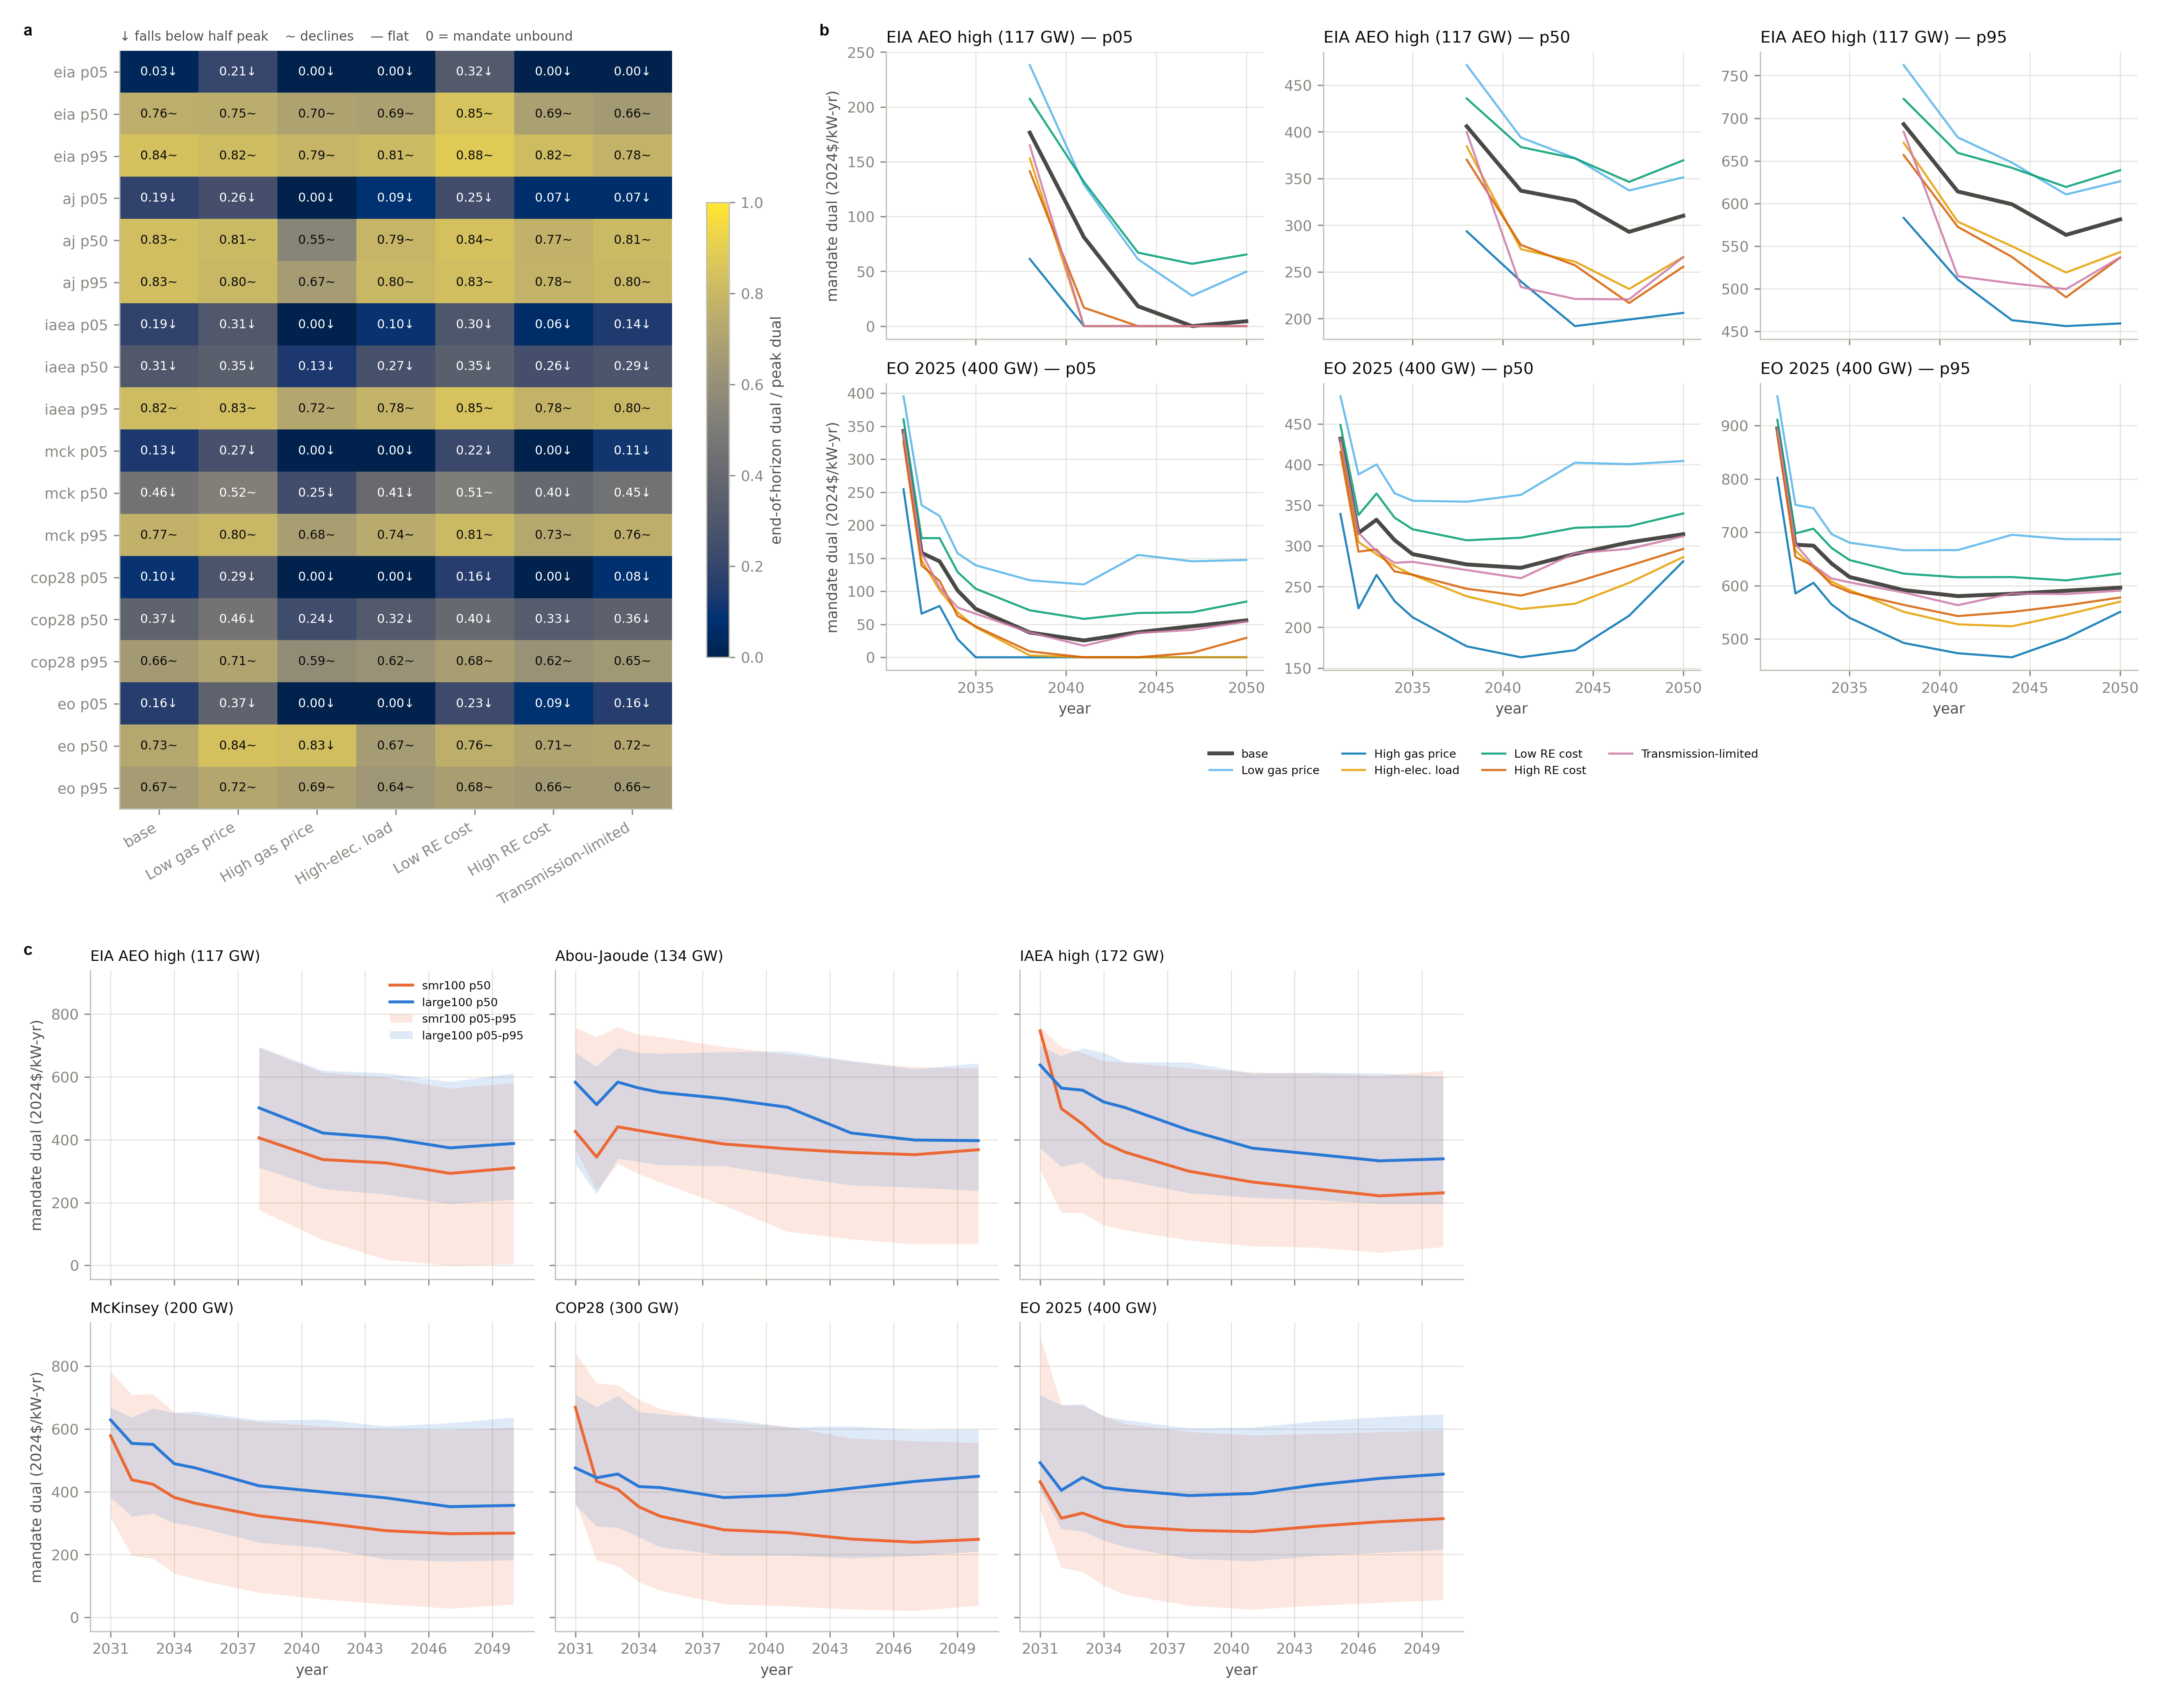

**Sources — edit the figure at its origin, not here:**

- `z-ethan\step4_analysis\figures\g02_shape_survival_matrix.png` — generated by `step4_analysis/step4_analysis.ipynb` (cell 11) from `step4_analysis/exports/s02_shape_survival.csv`
- `z-ethan\step4_analysis\figures\g03_dual_overlays.png` — generated by `step4_analysis/step4_analysis.ipynb` (cell 12) from step3+step4 checks `duals_by_year.csv` (eia/eo x p05/p50/p95 x 7 arms)
- `z-ethan\step3_analysis\figures\f15_large_band.png` — generated by `step3_analysis/step3_analysis.ipynb` (cell 23) from combined duals, large100 vs smr100 shared binding years; table: `t15_large_ratio.csv`

shape survival: 108/108
Kendall tau vs base (fiscal-bill metric, 18 non-base cells): min 0.867, mean 0.993
      min   max
pct            
p05  1.44  3.53
p50  1.23  1.36
p95  0.95  1.02

--- draft caption [Fig 6] ---
Robustness across market worlds (108 sensitivity runs: 18 cases x six market arms). (a) Bridge-
shape survival matrix: the shape survives in 108 of 108 cells — the expensive-world non-decay is
generic. (b) Shadow-price overlays for the ladder's end schedules across market worlds: only the
level moves, in the direction economics predicts (median -27% to +18%). (c) Large-reactor vs SMR
shadow prices by percentile: the large premium is 1.4-3.5x in cheap worlds and 1.23-1.36x at the
median, but the two technologies reach parity (0.95-1.02x) in expensive worlds.


In [7]:
P.compose(
    [[S4_FIG / "g02_shape_survival_matrix.png", S4_FIG / "g03_dual_overlays.png"],
     [S3_FIG / "f15_large_band.png"]],
    "Fig6_robustness.png",
)
P.source_ref(
    (S4_FIG / "g02_shape_survival_matrix.png", "step4_analysis/step4_analysis.ipynb", "cell 11",
     "`step4_analysis/exports/s02_shape_survival.csv`"),
    (S4_FIG / "g03_dual_overlays.png", "step4_analysis/step4_analysis.ipynb", "cell 12",
     "step3+step4 checks `duals_by_year.csv` (eia/eo x p05/p50/p95 x 7 arms)"),
    (S3_FIG / "f15_large_band.png", "step3_analysis/step3_analysis.ipynb", "cell 23",
     "combined duals, large100 vs smr100 shared binding years; table: `t15_large_ratio.csv`"),
)

s02 = pd.read_csv(S4_EXP / "s02_shape_survival.csv")
surv = s02[s02["survives"].notna()]
n_surv = int((surv["survives"] == "yes").sum())
print(f"shape survival: {n_surv}/{len(surv)}")
s03 = pd.read_csv(S4_EXP / "s03_ranking_preservation.csv")
fis = s03[(s03["metric"] == "disc_program_bill") & (s03["sens"] != "base")]
print(f"Kendall tau vs base (fiscal-bill metric, 18 non-base cells): "
      f"min {fis['kendall_tau_vs_base'].min():.3f}, "
      f"mean {fis['kendall_tau_vs_base'].mean():.3f}")
t15 = pd.read_csv(S3_EXP / "t15_large_ratio.csv")
print(t15.groupby("pct")["ratio_large_over_smr"].agg(["min", "max"]).round(2).to_string())

P.caption("Fig 6", f'''
Robustness across market worlds (108 sensitivity runs: 18 cases x six market arms).
(a) Bridge-shape survival matrix: the shape survives in {n_surv} of
{len(surv)} cells — the expensive-world non-decay is generic. (b) Shadow-price overlays
for the ladder's end schedules across market worlds: only the level moves, in the
direction economics predicts (median -27% to +18%). (c) Large-reactor vs SMR shadow
prices by percentile: the large premium is 1.4-3.5x in cheap worlds and 1.23-1.36x at
the median, but the two technologies reach parity (0.95-1.02x) in expensive worlds.
''')

## Table 1 — The six deployment schedules

**What this table shows.** One row for each deployment schedule. The
columns give the source, the source type, the 2050 target, and the
mandate that ReEDS enforces. The glossary defines "schedule" and
"mandate". This table replaces the case-level results table
(2026-08-19); the full case-level tables are in the SI (ST5, ST6).

**Source type.** Each schedule comes from a different type of source.
We call this type its "provenance class". The six classes are: a
modeled projection, a study assumption, an intergovernmental outlook,
a consultancy outlook, a pledge, and a policy aspiration. The paper
prices one schedule from each class. The paper does not rank the
schedules, and it gives them no probability weights.

**The two capacity columns.** `fleet_target_2050_GW` is the source's
target for the total US nuclear fleet in 2050. `new_capacity_2050_GW`
is the new capacity that the SMR-program mandate enforces by 2050.
This mandate counts post-2030 builds only (the "additions basis").
Three things make the gap between the two columns: the existing 2024
fleet (97 GW), the 3-GW index rounding correction, and any pre-2031
schedule growth, which the post-2030 mandate does not count (see
Methods).

**The large-reactor comparator.** `large_comparator_2050_GW` is the
2050 mandate of the large-reactor comparator runs. These mandates
count the whole fleet (the "fleet-inclusive basis"), because the
existing large fleet can satisfy a large-reactor floor. Each value
equals the mandated new capacity plus the existing fleet that
survives to 2050 under 80-year licenses. The code asserts this
identity.

**How to read a case name.** A case name joins a program family, a
schedule, and a cost world. Example: `smr100_eo_p95` is the 100%-SMR
program, on the 2025 EO schedule, in the expensive world.

In [8]:
t01 = pd.read_csv(S3_EXP / "t01_case_inventory.csv")

# Schedule metadata: token -> (source, provenance class). The tokens, the
# source names, and the one-per-class design are the locked schedule set
# (mc/mc_cost_trajectories.ipynb S2; outline I1).
SCHED_META = {
    "eia":   ("EIA 2026 AEO high",       "modeled projection"),
    "aj":    ("Abou-Jaoude mod",         "study assumption"),
    "iaea":  ("IAEA high",               "intergovernmental outlook"),
    "mck":   ("McKinsey GEP 2025",       "consultancy outlook"),
    "cop28": ("COP28 tripling pledge",   "pledge"),
    "eo":    ("2025 EO",                 "policy aspiration"),
}

smr = t01[t01["case"].str.startswith("smr100") & (t01["variant"] == "floor")]
lrg = t01[t01["case"].str.startswith("large100")]
rows = []
for tok, (source, sclass) in SCHED_META.items():
    s, l = smr[smr["schedule"] == tok], lrg[lrg["schedule"] == tok]
    # one mandate per schedule: identical across the three cost worlds
    for fam in (s, l):
        assert len(fam) == 3, (tok, len(fam))
        for col in ["ambition_2050_GW", "n_mandated_years",
                    "first_mandated_year", "mandate_2050_GW"]:
            assert fam[col].nunique() == 1, (tok, col)
    rows.append({
        "schedule": tok,
        "source": source,
        "provenance_class": sclass,
        "fleet_target_2050_GW": s["ambition_2050_GW"].iloc[0],
        "new_capacity_2050_GW": s["mandate_2050_GW"].iloc[0],
        "first_mandated_year": int(s["first_mandated_year"].iloc[0]),
        "n_mandated_years": int(s["n_mandated_years"].iloc[0]),
        "large_comparator_2050_GW": l["mandate_2050_GW"].iloc[0],
    })
table1 = pd.DataFrame(rows)
# fleet-inclusive comparator mandate = mandated additions + the one shared
# surviving-fleet term (the 2024 fleet net of 80-yr-license retirements;
# NOT fleet target - 3: aj's 1 GW of pre-2031 schedule growth is excluded
# from the post-2030 additions mandate)
fleet_2050 = (table1["large_comparator_2050_GW"]
              - table1["new_capacity_2050_GW"]).round(6)
assert fleet_2050.nunique() == 1 and 90.0 < fleet_2050.iloc[0] < 97.0, fleet_2050
print(f"existing fleet surviving to 2050 (shared across schedules): "
      f"{fleet_2050.iloc[0]:.1f} GW")
assert set(t01["schedule"]) == set(table1["schedule"])
table1.to_csv(P.OUT_EXP / "Table1_deployment_schedules.csv", index=False)
print(f"exports/Table1_deployment_schedules.csv ({len(table1)} rows)")

P.caption("Table 1", '''
The six deployment schedules. One schedule per provenance class; the paper prices the
schedules and does not rank or weight them. The fleet target is the source's 2050 goal
for the total US nuclear fleet. The SMR-program mandate enforces new capacity only
(additions basis); the large-reactor comparator mandates are fleet-inclusive (the same
mandated new capacity plus the existing fleet that survives to 2050 under 80-year
licenses). Mandated years are ReEDS solve years that carry
a mandate row. Sources: t01_case_inventory; the locked schedule set
(mc_cost_trajectories S2).
''')
table1

existing fleet surviving to 2050 (shared across schedules): 93.6 GW
exports/Table1_deployment_schedules.csv (6 rows)

--- draft caption [Table 1] ---
The six deployment schedules. One schedule per provenance class; the paper prices the schedules
and does not rank or weight them. The fleet target is the source's 2050 goal for the total US
nuclear fleet. The SMR-program mandate enforces new capacity only (additions basis); the large-
reactor comparator mandates are fleet-inclusive (the same mandated new capacity plus the
existing fleet that survives to 2050 under 80-year licenses). Mandated years are ReEDS solve
years that carry a mandate row. Sources: t01_case_inventory; the locked schedule set
(mc_cost_trajectories S2).


,schedule,source,provenance_class,fleet_target_2050_GW,new_capacity_2050_GW,first_mandated_year,n_mandated_years,large_comparator_2050_GW
0,eia,EIA 2026 AEO high,modeled projection,117.3,20.7,2038,5,114.3
1,aj,Abou-Jaoude mod,study assumption,134.0,36.4,2031,10,130.0
2,iaea,IAEA high,intergovernmental outlook,172.3,75.7,2031,10,169.3
3,mck,McKinsey GEP 2025,consultancy outlook,200.0,103.4,2031,10,197.0
4,cop28,COP28 tripling pledge,pledge,300.0,203.4,2031,10,297.0
5,eo,2025 EO,policy aspiration,400.0,303.4,2031,10,397.0


## Table 2 — freed reserve slot

The Monte Carlo variables table held this slot until 2026-08-19. It
moved to the SI as ST10 (appendix notebook): it is methods detail,
not a result, and the move frees the eighth display slot. Candidate
to refill the slot, decided at draft: the fiscal comparison (t12, now
ST7b). The other former candidate — promoting the closed-loop delivery
panel — is moot since 2026-08-24: the panel moved the other way, into
the SI (SF23a).

## Output manifest

Everything this notebook wrote, in one list. The composed figures are in
`figures/`; the tables and the draft captions are in `exports/`.

In [9]:
P.write_captions("main")
for f in sorted(P.OUT_FIG.glob("Fig*.png")):
    print(f"figures/{f.name}")
for f in sorted(P.OUT_EXP.glob("Table*.csv")):
    print(f"exports/{f.name}")

7 captions -> z-ethan\paper_figures\exports\captions_main.txt
figures/Fig1_atb_placement.png
figures/Fig2_schedules_and_cost_fans.png
figures/Fig3_technology_choice.png
figures/Fig4_shadow_price.png
figures/Fig5_required_itc_and_menu.png
figures/Fig6_robustness.png
exports/Table1_deployment_schedules.csv
